# Mohr-Coulomb Validation — Embedded Crack with Projected Radau Contact

Biaxial compression on a unit square with an embedded (non-through) crack.
The bulk poro-elastodynamic FEM assembly is kept intact; projected Radau
handles the nonsmooth crack contact in nodal traction units.


## 1. Imports

In [ ]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '4')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem.models.elasticity import lame_parameters

from poroelasticity import CGPoroelastostatics, CrackMeshBuilder, MaterialParams
from poroelasticity.config import ScaleFactors as _ScaleFactors
from poroelasticity.nondimensionalise import compute_dimensionless_params as _compute_ndp
from poroelasticity.cg_dashboard import CGPoroelasticDashboard

import solve_nivp
from solve_nivp.projected_radau_contact import build_projected_radau_contact


print(f"solve_nivp version: {getattr(solve_nivp, '__version__', 'dev')}")
print('Imports OK')


## 2. Configuration

`ALPHA_BIOT = 0` decouples fluid and solid — pure elastodynamics.  High bulk viscous
damping (`BULK_MU_V`, `BULK_LAM_V`) overdamps the system so the Radau IIA time-stepping
is effectively quasi-static.  The crack is embedded at `(0.5, 0.5)` with length 0.4,
well inside the unit square.

In [ ]:
# =====================================================================
# USER INPUTS — all in PHYSICAL units.
# SCALE_L and SCALE_EPS are nondim choices only; changing them must NOT
# change the physics, only the magnitude of internal dimensionless arrays.
# =====================================================================

# --- Material -------------------------------------------------------------
NU          = 0.3
G_SHEAR     = 10e3               # MPa
E_YOUNG     = 2.0 * G_SHEAR * (1.0 + NU)
ALPHA_BIOT  = 0.0
BETA_FLUID  = 8.5e-5             # 1/MPa
ETA_FLUID   = 2.0e-18 / 3600.0   # MPa·s
K_PERM      = 1.0e-15 * 1.0e-6   # m²
DENSITY_PHYS = 2.7e-3            # MPa-consistent (ρ_SI [kg/m³] / 1e6)
etad = 0.9e-1
BULK_MU_V   = 1.0e-1             # MPa·s, Kelvin–Voigt shear
BULK_LAM_V  = 1.0e-1             # MPa·s, Kelvin–Voigt bulk

# --- Geometry (PHYSICAL lengths) ------------------------------------------
# These are passed straight to CrackMeshBuilder; CGPoroelastostatics divides
# by SCALE_L internally (mesh.scaled(1/L)) to obtain the dimensionless mesh.
XMIN, XMAX = 0.0, 20.0
YMIN, YMAX = 0.0, 20.0
N_ELEM     = 40

CRACK_LENGTH = 6.0
CRACK_X0     = 10.0#0.5 * (XMIN + XMAX)
CRACK_Y0     = 10.0#0.5 * (YMIN + YMAX)

# --- Loading (physical) ---------------------------------------------------
SIGMA_RIGHT = 10.0                  # MPa, compression positive
SIGMA_TOP   = 50.0                  # MPa
MU = 0.6                            # static friction (matches slip-weakening μ_static)

# --- Crack hydraulic interface --------------------------------------------
CRACK_T_ROBIN = 0.0
CRACK_MODEL_PARAMS = {'T': CRACK_T_ROBIN, 'tangential_flow': False}

# --- Time (physical seconds) ----------------------------------------------
TMAX_PHYS = 1.1e-2   # seconds
H_PHYS    = 2.8e-6   # seconds

# --- Nondim choice (must NOT change physics) ------------------------------
SCALE_L     = 1.0
SCALE_EPS   = 1.0e-3

# --- Domain refinement knob (BOX_SCALE > 1: enlarge box, keep crack length) ---
BOX_SCALE = 1.0
XMAX *= BOX_SCALE
YMAX *= BOX_SCALE
CRACK_X0 = 0.5 * (XMIN + XMAX)
CRACK_Y0 = 0.5 * (YMIN + YMAX)
N_ELEM   = max(int(round(N_ELEM * BOX_SCALE)), N_ELEM)

# =====================================================================
# DERIVED QUANTITIES — recomputed on every run, do not edit.
# =====================================================================

LAM, MU_LAME = lame_parameters(E_YOUNG, NU)
PARAMS = (MU_LAME, LAM, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)
MATERIAL = MaterialParams(
    mu=MU_LAME, lam=LAM, alpha=ALPHA_BIOT,
    beta=BETA_FLUID, C=K_PERM / ETA_FLUID,
    rho=DENSITY_PHYS,
)
Mmod = LAM + 2 * MU_LAME
Sigma_scale = Mmod * SCALE_EPS
T_scale = _compute_ndp(MATERIAL, _ScaleFactors(L=SCALE_L, eps=SCALE_EPS)).T_scale

# Time: dimensionless τ = t_phys / T_scale
TMAX    = TMAX_PHYS / T_scale
H_FIXED = H_PHYS    / T_scale

# Output unit conversions (multiply dimensionless field by these to get physical).
LEN_UNIT_TO_PHYS    = SCALE_L              # x_phys [m]   = x_d * LEN_UNIT_TO_PHYS
DISP_UNIT_TO_PHYS   = SCALE_L * SCALE_EPS  # u_phys [m]   = u_d * DISP_UNIT_TO_PHYS
TIME_UNIT_TO_PHYS   = T_scale              # t_phys [s]   = t_d * TIME_UNIT_TO_PHYS
STRESS_UNIT_TO_PHYS = Sigma_scale          # σ_phys [MPa] = σ_d * STRESS_UNIT_TO_PHYS

S1 = max(SIGMA_RIGHT, SIGMA_TOP)
S3 = min(SIGMA_RIGHT, SIGMA_TOP)

print(f"Domain (PHYS):  [{XMIN},{XMAX}] × [{YMIN},{YMAX}],  N_ELEM = {N_ELEM}")
print(f"Crack  (PHYS):  centre=({CRACK_X0},{CRACK_Y0}), length={CRACK_LENGTH}")
print(f"Loading: σ_right={SIGMA_RIGHT}, σ_top={SIGMA_TOP}  →  σ₁={S1}, σ₃={S3}")
print(f"Friction: μ = {MU}")
print(f"Damping: bulk_mu_v={BULK_MU_V:.1e} MPa·s, bulk_lam_v={BULK_LAM_V:.1e} MPa·s")
print(f"Hydraulic crack: Robin T = {CRACK_T_ROBIN}  (0 ⇒ sealed)")
print(f"Nondim:  Mmod={Mmod:.0f} MPa, Σ_scale={Sigma_scale:.1f} MPa, T_scale={T_scale:.3e} s")
print(f"Time:    TMAX_PHYS={TMAX_PHYS:.3e} s, H_PHYS={H_PHYS:.3e} s  "
      f"(dimensionless: tmax={TMAX:.3g}, h={H_FIXED:.3g})")

# --- Loading mode ---------------------------------------------------------
LOADING_MODE    = 'prestress'   # 'prestress' | 'displacement'
TOP_COMPRESSION = 0.1            # m  (used only when LOADING_MODE == 'displacement')
T_LOAD          = TMAX           # ramp duration (dimensionless)

def make_bc():
    """Build the BC dict for the active LOADING_MODE."""
    dp_rate = {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0}
    if LOADING_MODE == 'prestress':
        return {
            'dp_rate': dp_rate,
        }
    if LOADING_MODE == 'displacement':
        return {
            'v1': {'bottom': 0.0},
            'v2': {'bottom': 0.0},
            'v2_rate': {'top': -TOP_COMPRESSION / T_LOAD},
            'dp_rate': dp_rate,
        }
    raise ValueError(f"unknown LOADING_MODE {LOADING_MODE!r}")

def prestress_offsets(sigma_N_phys, tau_phys):
    """Return (sigma_N, tau) used as Mohr offsets s0, w0 (physical units)."""
    if LOADING_MODE == 'prestress':
        return sigma_N_phys, tau_phys
    return 0.0, 0.0

print(f"LOADING_MODE = {LOADING_MODE!r};  top compression = {TOP_COMPRESSION} m over T_LOAD = {T_LOAD}")


# --- Density convention (READ ME) -----------------------------------------
print(f"physical density: DENSITY_PHYS = {DENSITY_PHYS:.3g} (MPa-consistent units); "
      f"library will compute ρ_d via ρ·L²/(T²·Mmod)")

RAMP_HOLD_AFTER = True

def make_hold_bc(top_displacement_phys):
    """Phase-2 BC: pin top to a fixed displacement (m), no rate."""
    return {
        'v1': {'bottom': 0.0},
        'v2': {'bottom': 0.0, 'top': float(top_displacement_phys)},
        'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
    }

# --- Adaptive integrator constants ---------------------------------------
ADAPTIVE_RTOL  = 1.0e-3
ADAPTIVE_ATOL  = 1.0e-6
ADAPTIVE_H_MIN = 1.0e-5
ADAPTIVE_H_MAX = TMAX/10
H0_ADAPTIVE    = H_FIXED

# --- Lysmer-Kuhlemeyer absorbing boundary (prestress mode only) -----------
USE_LYSMER  = (LOADING_MODE == 'prestress')
LYSMER_AP   = 1.0
LYSMER_AS   = 1.0


def build_lysmer_damping(poro, a_p=None, a_s=None):
    """Lysmer absorbing-boundary damping matrix in DIMENSIONLESS units (Nu × Nu)."""
    from skfem import FacetBasis, BilinearForm
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS

    E_phys, nu_phys = E_YOUNG, NU
    rho_phys = MATERIAL.rho
    Vp_phys = np.sqrt(E_phys * (1.0 - nu_phys)
                      / ((1.0 + nu_phys) * (1.0 - 2.0 * nu_phys) * rho_phys))
    Vs_phys = np.sqrt(E_phys / (2.0 * (1.0 + nu_phys) * rho_phys))

    L_scale = SCALE_L
    T_scale_loc = _compute_ndp(MATERIAL, _ScaleFactors(L=L_scale, eps=SCALE_EPS)).T_scale
    Vp_d = Vp_phys * T_scale_loc / L_scale
    Vs_d = Vs_phys * T_scale_loc / L_scale

    rho_d = float(poro.rho_d)
    c_n = a_p * rho_d * Vp_d
    c_t = a_s * rho_d * Vs_d

    fb = FacetBasis(poro.mesh, poro.basis_u.elem,
                    facets=poro.mesh.boundary_facets(),
                    intorder=poro.intorder)

    @BilinearForm
    def lysmer_form(u, v, w):
        n = w.n
        u_n = u[0] * n[0] + u[1] * n[1]
        v_n = v[0] * n[0] + v[1] * n[1]
        u_tx = u[0] - u_n * n[0]; u_ty = u[1] - u_n * n[1]
        v_tx = v[0] - v_n * n[0]; v_ty = v[1] - v_n * n[1]
        return c_n * u_n * v_n + c_t * (u_tx * v_tx + u_ty * v_ty)

    return lysmer_form.assemble(fb)


def lysmer_descriptor_block(poro, n_phys, n_base, a_p=None, a_s=None):
    """C_lysmer (Nu × Nu) embedded as an n_phys × n_phys sparse matrix."""
    if a_p is None: a_p = LYSMER_AP
    if a_s is None: a_s = LYSMER_AS
    C_l = build_lysmer_damping(poro, a_p=a_p, a_s=a_s).tocsr()
    Nu = C_l.shape[0]
    if n_phys - n_base != Nu:
        raise ValueError(f"Lysmer block sizing mismatch: Nu={Nu} vs n_phys-n_base={n_phys-n_base}")
    Z_top = sp.csr_matrix((n_base, n_phys))
    Z_left = sp.csr_matrix((Nu, n_base))
    bottom = sp.hstack([Z_left, C_l], format='csr')
    return sp.vstack([Z_top, bottom], format='csr')

print(f"USE_LYSMER = {USE_LYSMER}  (a_p={LYSMER_AP}, a_s={LYSMER_AS})")

# --- Warm-start helper: Coulomb-cone projection of the prestress offset --
def coulomb_cone_warm_start(s0_arr, w0_arr, mu):
    s0_arr = np.asarray(s0_arr, dtype=float).ravel()
    w0_arr = np.asarray(w0_arr, dtype=float).ravel()
    mu = float(mu)
    inv = 1.0 / (1.0 + mu * mu)
    out = np.zeros(2 * s0_arr.size)
    for k in range(s0_arr.size):
        sN, w = float(s0_arr[k]), float(w0_arr[k])
        aw = abs(w)
        if sN >= 0.0 and aw <= mu * sN:
            r_n_p, r_t_p = sN, w
        elif mu * sN + aw <= 0.0:
            r_n_p, r_t_p = 0.0, 0.0
        else:
            r_n_p = max((sN + mu * aw) * inv, 0.0)
            r_t_p = mu * r_n_p * (1.0 if w >= 0 else -1.0)
        out[2 * k]     = r_n_p - sN
        out[2 * k + 1] = r_t_p - w
    return out

CONTACT_LAW = 'soc_fb'
print(f"contact_law = {CONTACT_LAW!r}")


Domain (PHYS):  [0.0,20.0] × [0.0,20.0],  N_ELEM = 40
Crack  (PHYS):  centre=(10.0,10.0), length=6.0
Loading: σ_right=10.0, σ_top=50.0  →  σ₁=50.0, σ₃=10.0
Friction: μ = 0.6
Damping: bulk_mu_v=1.0e-01 MPa·s, bulk_lam_v=1.0e-01 MPa·s
Hydraulic crack: Robin T = 0.0  (0 ⇒ sealed)
Nondim:  Mmod=35000 MPa, Σ_scale=35.0 MPa, T_scale=2.777e-04 s
Time:    TMAX_PHYS=1.100e-02 s, H_PHYS=2.800e-06 s  (dimensionless: tmax=39.6, h=0.0101)
LOADING_MODE = 'prestress';  top compression = 0.1 m over T_LOAD = 39.60452649027025
physical density: DENSITY_PHYS = 0.0027 (MPa-consistent units); library will compute ρ_d via ρ·L²/(T²·Mmod)
USE_LYSMER = True  (a_p=1.0, a_s=1.0)
contact_law = 'soc_fb'


## 3. Analytical Mohr-Coulomb

On a plane at angle θ from σ₁ (compression positive):

$$\sigma_N(\theta) = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2}\cos 2\theta, \qquad
\tau(\theta) = \frac{\sigma_1 - \sigma_3}{2}\sin 2\theta$$

Coulomb failure (cohesionless): $|\tau| = \mu\,\sigma_N$.

The **failure plane angle** $\theta_{\mathrm{crit}} = \tfrac{1}{2}\arctan(1/\mu)$ maximises
the ratio $|\tau|/\mu\sigma_N$ over all orientations.  When the Mohr circle extends past
the Coulomb envelope — as it does here — there is a **range** of orientations
$[\theta_{\mathrm{onset}},\,\theta_{\mathrm{upper}}]$ where $|\tau| > \mu\sigma_N$.

**Angle convention:** `CrackMeshBuilder` parameterizes `crack_theta` as the angle of the
crack *line* measured counter-clockwise from the y-axis.  With σ₁ vertical, a Mohr angle
θ from σ₁ corresponds to `crack_theta = π/2 − θ`.

In [82]:
phi = np.arctan(MU)
theta_crit = 0.5 * np.arctan(1.0 / MU)

a_mc = (S1 - S3) / 2
R_mc = a_mc * np.sqrt(1 + MU**2)
sin_arg = MU * (S1 + S3) / (2 * R_mc)
theta_onset = 0.5 * (phi + np.arcsin(sin_arg))
theta_upper = 0.5 * (phi + np.pi - np.arcsin(sin_arg))

THETA_LOCKED  = np.radians(20.0)
THETA_SLIDING = np.radians(60)

def mohr_tractions(theta):
    sigma_N = (S1 + S3) / 2 + (S1 - S3) / 2 * np.cos(2 * theta)
    tau     = (S1 - S3) / 2 * np.sin(2 * theta)
    return sigma_N, tau

sN_locked,  tau_locked  = mohr_tractions(THETA_LOCKED)
sN_sliding, tau_sliding = mohr_tractions(THETA_SLIDING)

CRACK_THETA_LOCKED  = np.pi / 2 - THETA_LOCKED
CRACK_THETA_SLIDING = np.pi / 2 - THETA_SLIDING

print(f"θ_crit  = {np.degrees(theta_crit):.2f}° (failure plane angle)")
print(f"Failure zone: [{np.degrees(theta_onset):.2f}°, {np.degrees(theta_upper):.2f}°]")
print(f"φ = arctan(μ) = {np.degrees(phi):.2f}°")
print()
print(f"Locked test  (θ = {np.degrees(THETA_LOCKED):.0f}° < θ_onset = {np.degrees(theta_onset):.1f}°):")
print(f"  σ_N = {sN_locked:.2f},  τ = {tau_locked:.2f},  μσ_N = {MU*sN_locked:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_locked)/(MU*sN_locked):.4f}  (< 1 → locked)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_LOCKED):.1f}°")
print()
print(f"Sliding test (θ = {np.degrees(THETA_SLIDING):.0f}° ∈ failure zone):")
print(f"  σ_N = {sN_sliding:.2f},  τ = {tau_sliding:.2f},  μσ_N = {MU*sN_sliding:.2f}")
print(f"  |τ|/μσ_N = {abs(tau_sliding)/(MU*sN_sliding):.4f}  (> 1 → sliding)")
print(f"  crack_theta = {np.degrees(CRACK_THETA_SLIDING):.1f}°")

θ_crit  = 29.52° (failure plane angle)
Failure zone: [40.74°, 80.23°]
φ = arctan(μ) = 30.96°

Locked test  (θ = 20° < θ_onset = 40.7°):
  σ_N = 45.32,  τ = 12.86,  μσ_N = 27.19
  |τ|/μσ_N = 0.4728  (< 1 → locked)
  crack_theta = 70.0°

Sliding test (θ = 60° ∈ failure zone):
  σ_N = 20.00,  τ = 17.32,  μσ_N = 12.00
  |τ|/μσ_N = 1.4434  (> 1 → sliding)
  crack_theta = 30.0°


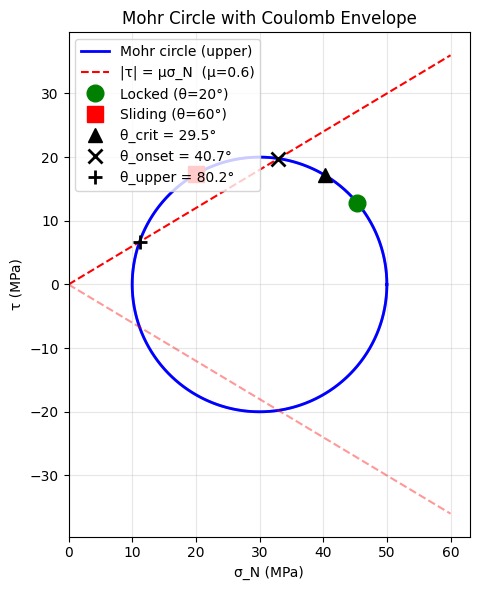

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))

theta_range = np.linspace(0, np.pi, 300)
sN_range, tau_range = mohr_tractions(theta_range)
ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle (upper)')
ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

sN_env = np.linspace(0, S1 * 1.2, 100)
ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'|τ| = μσ_N  (μ={MU})')
ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

ax.plot(sN_locked, tau_locked, 'go', ms=12, zorder=5,
        label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°)')
ax.plot(sN_sliding, tau_sliding, 'rs', ms=12, zorder=5,
        label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°)')

sN_crit, tau_crit = mohr_tractions(theta_crit)
ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
        label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

sN_on, tau_on = mohr_tractions(theta_onset)
sN_up, tau_up = mohr_tractions(theta_upper)
ax.plot(sN_on, tau_on, 'kx', ms=10, mew=2, zorder=5,
        label=f'θ_onset = {np.degrees(theta_onset):.1f}°')
ax.plot(sN_up, tau_up, 'k+', ms=10, mew=2, zorder=5,
        label=f'θ_upper = {np.degrees(theta_upper):.1f}°')

ax.set_xlabel('σ_N (MPa)')
ax.set_ylabel('τ (MPa)')
ax.set_title('Mohr Circle with Coulomb Envelope')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

## 4. Build Conforming Mesh (Locked Test, θ = 20°)

In [84]:
builder = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_LOCKED,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=True,
    verbose=True,
)
mesh, el_p, el_u, crack, h_mesh = builder.build()
print(f"h ≈ {h_mesh:.4f},  elements = {mesh.nelements},  vertices = {mesh.p.shape[1]}")


Conforming tri mesh: 4172 elements, h=0.5000
[RobustCrackGenerator] Conforming shortcut: 12 crack-aligned facets found — using directly
[RobustCrackGenerator] Timing breakdown:
    setup                             25.8 ms
    conforming_check                  22.3 ms
    find_facets_intersected            0.0 ms
    find_elements_intersected          0.0 ms
    get_candidate_facets               0.0 ms
    compute_metrics                    0.0 ms
    path_selection                     0.0 ms
    TOTAL                             48.1 ms
[RobustCrackGenerator] Surrogate facets: 12
  Alignment: mean=1.000, min=1.000
  |δ|/h:    mean=0.000, max=0.000

Mesh: 2167 vertices, 4172 elements
Crack: 12 surrogate facets
h = 0.5
h ≈ 0.5000,  elements = 4172,  vertices = 2167


## 5. Assemble CG Solver

`crack_law='nonsmooth'` sets K = I (pure displacement-jump evaluator).
`rotate_crack_to_nt=True` separates normal and tangential DOFs at the crack interface.
Roller BCs: left (v₁ = 0), bottom (v₂ = 0).  No traction BCs — the entire background
stress is carried by s0/w0 offsets.

In [85]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    bc = make_bc()

    poro = CGPoroelastostatics(
        mesh=mesh,
        element_p=el_p,
        element_u=el_u,
        params=PARAMS, material=MATERIAL,
        crack=crack,
        model_params=CRACK_MODEL_PARAMS,
        intorder=6,
        scales=(SCALE_L, SCALE_EPS),
        bc=bc,
        P_scale=None,
        verbose=True,
        free_memory=False,
        enforcement_type='nodal',
        apply_transform=True,
        include_taylor=False,
        include_hessian=False,
        include_sbm=False,
        crack_law='nonsmooth',
        rotate_crack_to_nt=True,
        bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
    )

    print(f"ndofs = {poro.ndofs}")
    print(f"  Np = {poro.basis_p.N},  Nu = {poro.basis_u.N}")
    print(f"  n_lambda_q = {poro.n_lambda_q},  n_lambda_sigma = {poro.n_lambda_sigma}")
    print(f"  crack_law = nonsmooth,  rotated_to_nt = {poro._transform_info.get('rotated_to_nt')}")

Mesh split along crack:
  Original: 2167 vertices, 4172 elements
  Split: 2178 vertices, 4172 elements
  Crack facets: 12 plus, 12 minus
  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 12
  Number of DOFs: 2178
  Size: 3456 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7cb4db1649d0>
  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 12
  Number of DOFs: 12700
  Size: 18432 B
  Projected 0 / 48 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x7cb4db165590>
SBM geometry cache: 192 QPs pre-computed in 1.7 ms
Crack interface assembled (Spring law + SBM corrections):
  Robin T = 0.00e+00 (dimensionless: 0.00e+00)
  Spring k_n = None (dimensionless: 1.00e+00)
  Spring k_t = None (dimensionless: 1.00e+00)
  Enforcem

## 6. Projection and Dynamic System

`strip_multiplier_dynamics()` zeros the multiplier rows of `M` so the algebraic
projection owns them.  `build_projection()` builds the constraint projection.
`build_first_order_dynamic_system()` lifts to descriptor form `A_dyn · ẋ = rhs(t, x)`.

In [86]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    poro.strip_multiplier_dynamics()
    projection, meta = poro.build_projection()

    dyn = poro.build_first_order_dynamic_system(meta)

    A_dyn          = dyn['A']
    rhs_dyn        = dyn['rhs']
    rhs_jac_dyn    = dyn['rhs_jac']
    velocity_slice = dyn['velocity_slice']
    n_base         = dyn['n_base']
    comp_slices    = dyn['component_slices']
    nl_atol_dyn    = dyn['nl_atol_per_block']

    Np = poro.basis_p.N
    Nu = poro.basis_u.N

    print(f"n_base = {n_base},  |x| = {A_dyn.shape[0]},  nnz(A_dyn) = {A_dyn.nnz}")
    print(f"velocity_slice = {velocity_slice}")
    print(f"component_slices: {len(comp_slices)} blocks")

build_projection():
  Flux constraint:     C_q shape=(22, 14878)
  Traction constraint: C_s shape=(44, 14878)
  Projection type:     AlgebraicConstraintProjection
  Component slices:    13 blocks
n_base = 14944,  |x| = 27644,  nnz(A_dyn) = 115759
velocity_slice = slice(14944, np.int32(27644), None)
component_slices: 18 blocks


### 6a. Descriptor Pencil Diagnostics

In [87]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    A_csr = A_dyn.tocsr()
    J_csr = rhs_jac_dyn(0.0, np.zeros(A_dyn.shape[0])).tocsr()

    row_p   = slice(0, Np)
    row_u   = slice(Np, Np + Nu)
    row_lam = slice(Np + Nu, n_base)
    row_mom = slice(n_base, n_base + Nu)

    def fro(block):
        return float(sp.linalg.norm(block, 'fro')) if block.nnz else 0.0

    print("=== A_dyn block norms (descriptor mass) ===")
    print(f"  ||A[p, z]||   = {fro(A_csr[row_p, :n_base]):.3e}")
    print(f"  ||A[kin, z]||  = {fro(A_csr[row_u, :n_base]):.3e}")
    print(f"  ||A[lam, :]||  = {fro(A_csr[row_lam, :]):.3e}  (expect 0 — stripped)")
    print(f"  ||A[mom, v]||  = {fro(A_csr[row_mom, n_base:]):.3e}  (FE inertia)")
    print()
    print("=== J_dyn block norms (RHS Jacobian) ===")
    print(f"  ||J[mom, z]||  = {fro(J_csr[row_mom, :n_base]):.3e}  (stiffness)")
    print(f"  ||J[mom, v]||  = {fro(J_csr[row_mom, n_base:]):.3e}  (damping)")

=== A_dyn block norms (descriptor mass) ===
  ||A[p, z]||   = 1.351e+01
  ||A[kin, z]||  = 1.127e+02
  ||A[lam, :]||  = 0.000e+00  (expect 0 — stripped)
  ||A[mom, v]||  = 8.000e+00  (FE inertia)

=== J_dyn block norms (RHS Jacobian) ===
  ||J[mom, z]||  = 4.781e+02  (stiffness)
  ||J[mom, v]||  = 1.523e+01  (damping)


## 7. Projected Radau Contact Wiring

Build extraction matrices and traction coupling directly from `_transform_info` offsets.
With `rotate_crack_to_nt=True`, the transformed state exposes `[[u_n]]` and `[[u_t]]`
as contiguous blocks at known offsets.

- `C_extract` selects displacement jumps `[[u_n]], [[u_t]]` from the dynamic state.
- `D_extract` selects velocity jumps `[[v_n]], [[v_t]]` from the explicit velocity block.
- `B` is the weak-form traction distribution from the transformed `[[λ_σ]]` columns.

The contact solver receives effective nodal tractions.  Interface quadrature weights stay
inside `B`; Mohr offsets are therefore passed as pure nodal tractions, not multiplied by
`omega`.  The Biot pressure part of the normal total traction is split into the smooth
RHS as `-α B_n C_{p,Γ} x`, so mechanics still receives total traction while the cone sees
effective normal traction.


In [88]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:

    info = poro._transform_info
    n_c  = int(poro.n_lambda_q)
    dim  = int(poro.dim)

    lam_s_sl = meta['lam_s_sl']

    off_jmpu  = info['off_jmpu']
    n_iu      = info['n_intf_u']
    off_jmpls = info['off_jmpls']
    n_lsig    = info['n_lam_sig']

    # With rotate_crack_to_nt: [[u_n]](n_c) then [[u_t]](n_c)
    jmpu_n_indices = np.arange(off_jmpu, off_jmpu + n_c)
    jmpu_t_indices = np.arange(off_jmpu + n_c, off_jmpu + n_iu)
    jmpu_all = np.concatenate([jmpu_n_indices, jmpu_t_indices])

    jmpls_cols = np.arange(off_jmpls, off_jmpls + n_lsig)

    print(f"Interface nodes:  n_c = {n_c}")
    print(f"[[u_n]] indices:  {jmpu_n_indices[0]}..{jmpu_n_indices[-1]}")
    print(f"[[u_t]] indices:  {jmpu_t_indices[0]}..{jmpu_t_indices[-1]}")
    print(f"[[λ_σ]] columns:  {jmpls_cols[0]}..{jmpls_cols[-1]}")

    T_u_mat = dyn['T_u']
    u_idx   = dyn['u_state_indices']
    jmpu_local = np.searchsorted(u_idx, jmpu_all)
    assert np.all(u_idx[jmpu_local] == jmpu_all), "[[u]] DOFs not found in u_state"
    D = T_u_mat[jmpu_local, :].tocsr()

    R_v = dyn.get('R_v')
    A_csr = poro.A.tocsr()
    B_u = (A_csr[Np:Np + Nu, :][:, jmpls_cols]).tocsr()
    if R_v is not None:
        B_u = (R_v @ B_u).tocsr()

    dirichlet_local = np.array(
        [d - Np for d in np.asarray(getattr(poro, '_dirichlet_dof_set', []), dtype=int)
         if Np <= d < Np + Nu],
        dtype=int,
    )
    if dirichlet_local.size:
        B_u = B_u.tolil()
        B_u[dirichlet_local, :] = 0.0
        B_u = B_u.tocsr()

    scale = h_mesh / 2.0
    err_wc = sp.linalg.norm(B_u - scale * D.T) / sp.linalg.norm(B_u)
    print(f"\nUniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc:.2e}")
    print("  Exact contact weights are checked below through D_contact @ B.")

    # Projected Radau reactions are ordered per contact block:
    # [r_n0, r_t0, r_n1, r_t1, ...].  The transformed λ jump columns are
    # grouped [all σ_n, all τ], so permute B into contact-block order.
    perm = [idx for k in range(n_c) for idx in (k, n_c + k)]
    B_u_perm = B_u[:, perm].tocsr()
    reaction_rows = np.array([row for k in range(n_c) for row in (k, n_c + k)], dtype=int)

    contacts = [
        {
            'vel_normal_idx': k,
            'vel_tangential_idx': [n_c + k],
            'mu': MU,
            'e': 0.0,
        }
        for k in range(n_c)
    ]

    print(f"\nContact blocks: {len(contacts)}")


Interface nodes:  n_c = 11
[[u_n]] indices:  14856..14866
[[u_t]] indices:  14867..14877
[[λ_σ]] columns:  14922..14943

Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 3.19e-15
  Exact contact weights are checked below through D_contact @ B.

Contact blocks: 11


In [89]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:

    # Build first-order dynamic contact matrices in the augmented physical state y=[z; v].
    n_phys_locked = A_dyn.shape[0]
    n_aug_phys = n_phys_locked
    n_vel = n_aug_phys - n_base
    n_extract = 2 * n_c

    # Gap rows are grouped [all [[u_n]], all [[u_t]]] in the transformed base state.
    gap_extract_dyn = sp.csr_matrix(
        (np.ones(n_extract), (np.arange(n_extract), jmpu_all)),
        shape=(n_extract, n_aug_phys),
    )

    # Velocity rows use the explicit velocity block returned by build_first_order_dynamic_system.
    vel_extract_dyn = sp.hstack(
        [sp.csr_matrix((n_extract, n_base)), D],
        format='csr',
    )

    # Weak-form traction coupling.  B_u_perm columns are already in contact-block order.
    B_c_dyn = sp.vstack(
        [sp.csr_matrix((n_base, B_u_perm.shape[1])), B_u_perm],
        format='csr',
    )
    B_dyn = B_c_dyn
    B_n_dyn = B_c_dyn[:, 0::2]
    B_t_dyn = B_c_dyn[:, 1::2]

    # Contact-space work-conjugacy check in the same interleaved order used by Radau.
    vel_contact_extract_dyn = vel_extract_dyn[reaction_rows, :].tocsr()
    M_cc = (vel_contact_extract_dyn @ B_c_dyn).toarray()
    off_diag = np.max(np.abs(M_cc - np.diag(np.diag(M_cc))))
    omega = np.diag(M_cc)
    omega_n = omega[0::2]
    omega_t = omega[1::2]
    print(f"D_contact @ B diag range: {omega.min():.3e} .. {omega.max():.3e}; offdiag max {off_diag:.3e}")
    assert np.all(omega > 0), "Expected positive weak-form interface weights"
    assert off_diag < 1e-10 * max(1.0, np.max(np.abs(omega))), "D_contact @ B should be diagonal for nodal contact"
    assert np.allclose(omega_n, omega_t, rtol=1e-12, atol=1e-12)

    # Crack pressure trace used by the later alpha-coupled effective-traction split.
    # For the alpha-zero validation this contributes exactly zero, but keeping the
    # matrix explicit prevents the mechanics/cone split from drifting later.
    off_avgp = info['off_avgp']
    n_intf_p = info['n_intf_p']
    assert n_intf_p == n_c, "This notebook assumes one pore-pressure trace value per contact node"
    p_gamma_extract_dyn = sp.csr_matrix(
        (np.ones(n_c), (np.arange(n_c), off_avgp + np.arange(n_c))),
        shape=(n_c, n_aug_phys),
    )
    pressure_normal_correction = -ALPHA_BIOT * (B_n_dyn @ p_gamma_extract_dyn)
    pressure_normal_correction.eliminate_zeros()

    # # Alpha-zero verification: mechanics and cone tractions coincide in this phase.
    # assert ALPHA_BIOT == 0.0, "Alpha-zero validation expects ALPHA_BIOT = 0.0"
    # assert gap_extract_dyn.shape == (n_extract, n_aug_phys)
    # assert vel_extract_dyn.shape == (n_extract, n_aug_phys)
    # assert vel_contact_extract_dyn.shape == (n_extract, n_aug_phys)
    # assert B_c_dyn.shape == (n_aug_phys, n_extract)
    # assert B_n_dyn.shape == (n_aug_phys, n_c)
    # assert B_t_dyn.shape == (n_aug_phys, n_c)
    # assert p_gamma_extract_dyn.shape == (n_c, n_aug_phys)
    # assert pressure_normal_correction.nnz == 0, "Alpha-zero phase should have no pressure-normal correction"
    # print("Alpha-zero matrix/unit checks: PASS")

    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out

    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

    def _contact_history(y_hist, n_phys, n_contact, s0, w0):
        y_hist = np.asarray(y_hist, dtype=float)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
        r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
        return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

    if USE_LYSMER:
        _C_lysmer_locked = lysmer_descriptor_block(
            poro, n_phys_locked, n_base, a_p=LYSMER_AP, a_s=LYSMER_AS,
        )
    else:
        _C_lysmer_locked = None

    def rhs_dyn_eff(t, y, *extra):
        out = rhs_dyn(t, y, *extra) + pressure_normal_correction @ y
        if _C_lysmer_locked is not None:
            out = out - _C_lysmer_locked @ y
        return out

    def rhs_jac_dyn_eff(t, y, *extra):
        J = rhs_jac_dyn(t, y, *extra) + pressure_normal_correction
        if _C_lysmer_locked is not None:
            J = J - _C_lysmer_locked
        return J


D_contact @ B diag range: 5.000e-01 .. 5.000e-01; offdiag max 1.388e-17


In [ ]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:

    # Locked case: pure effective-traction offsets (not multiplied by interface weights).
    sigma_N_locked, tau_locked_val = mohr_tractions(THETA_LOCKED)
    _sN_phys, _tau_phys = prestress_offsets(sigma_N_locked, tau_locked_val)
    _s0_val = np.full(n_c, _sN_phys / Sigma_scale)
    _w0_val = np.full(n_c, _tau_phys / Sigma_scale)
    # assert _s0_val.shape == (n_c,)
    # assert _w0_val.shape == (n_c,)
    # assert np.allclose(_s0_val, sigma_N_locked / Sigma_scale)
    # assert np.allclose(_w0_val, tau_locked_val / Sigma_scale)

    def get_s0_locked(y):
        return _s0_val

    def get_w0_locked(y, k):
        return np.array([_w0_val[int(k)]])

    # Keep the flux Robin law algebraic.  Replace the whole transformed traction
    # closure row by zero; contact supplies the effective traction through B_c_dyn.
    flux_constraint = meta['constraints'][0]
    n_lam_s_dim = int(lam_s_sl.stop - lam_s_sl.start)
    zero_lam_s = {
        'g': lambda zf, *_a, _n=n_lam_s_dim: np.zeros(_n),
        'dg_dy': lambda zf, *_a, _n=n_lam_s_dim: np.zeros((_n, _n)),
        'y_slice': lam_s_sl,
        'q_slice': lam_s_sl,
    }

    cs = build_projected_radau_contact(
        A_dyn,
        rhs_dyn_eff,
        np.zeros(A_dyn.shape[0]),
        contacts=contacts,
        C_extract=gap_extract_dyn,
        D_extract=vel_extract_dyn,
        B=B_c_dyn,
        constraints=[flux_constraint, zero_lam_s],
        component_slices=comp_slices,
        rhs_jac=rhs_jac_dyn_eff,
        get_s0=get_s0_locked,
        get_w0=get_w0_locked,
        normal_r='auto',
        friction_r='auto',
        endpoint_inactive_handling='natural_map',
        contact_law=CONTACT_LAW,
        reported_reaction_units='force',
        auto_rho_strategy='delassus',
    )
    print("locked contact system:", cs.A.shape, "unknowns", cs.y0.size, "pure traction offsets")


locked contact system: (27666, 27666) unknowns 27666 pure traction offsets


## 8. Initial Condition

Zero perturbation everywhere — the background stress is entirely in s0/w0.

In [91]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    y0_locked = cs.y0.copy()
    y0_locked[-2 * n_c:] = coulomb_cone_warm_start(_s0_val, _w0_val, MU)

    print(f"|y0| = {np.linalg.norm(y0_locked):.4e}")
    print(f"  (should be ~0 — pure perturbation problem)")

|y0| = 0.0000e+00
  (should be ~0 — pure perturbation problem)


## 9. Solve — Locked Test (θ = 20° < θ_onset)

The resolved shear stress is below the Coulomb threshold, so the crack should remain
locked: zero perturbation displacement, zero slip.

In [92]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    n_aug_locked = cs.y0.size
    n_phys_locked = A_dyn.shape[0]

    nl_atol_locked = np.full(n_aug_locked, 1e-8)
    nl_rtol_locked = np.full(n_aug_locked, 1e-6)
    nl_atol_locked[n_phys_locked:] = 1e-10
    nl_rtol_locked[n_phys_locked:] = 0.0

    solver_opts_locked = dict(cs.solver_opts)
    solver_opts_locked.update(
        tol=1e-12,
        max_iter=500,
        rhs_jac=cs.rhs_jac,
        linear_solver='petsc',
        petsc_options={
            'ksp_type': 'preonly',
            'pc_type': 'lu',
            'pc_factor_mat_solver_type': 'mumps',
        },
    )

    integrator_opts_locked = dict(cs.integrator_opts)
    integrator_opts_locked.update({'stages': 2, 'use_coupled_newton': True})


    print(
        f"Solving locked test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), "
        f"h0={H0_ADAPTIVE}, tmax={TMAX}, rtol={ADAPTIVE_RTOL}, atol={ADAPTIVE_ATOL}"
    )

    (
        t_locked, y_locked, h_locked, fk_locked, info_locked, attempts_locked
    ) = solve_nivp.solve_ivp_ns(
        fun=cs.rhs,
        t_span=(0, TMAX),
        y0=y0_locked,
        method='radau_iia',
        integrator_opts=integrator_opts_locked,
        projection=cs.projection,
        solver='semismooth_newton',
        projection_opts={'component_slices': cs.component_slices},
        solver_opts=solver_opts_locked,
        adaptive=True,
        h0=H0_ADAPTIVE,
        rtol=ADAPTIVE_RTOL,
        atol=ADAPTIVE_ATOL,
        skip_error_indices=[0],
        active_set_filter=False,
        return_attempts=True,
        adaptive_opts=dict(
            h0=H0_ADAPTIVE,
            h_min=ADAPTIVE_H_MIN,
            h_max=ADAPTIVE_H_MAX,
            h_up=2.0,
            h_down=0.5,
            method_order=1,
        ),
        nl_atol=nl_atol_locked,
        nl_rtol=nl_rtol_locked,
        component_slices=cs.component_slices,
        verbose=True,
        A=cs.A,
        dae_var_weight='auto',
    )

    h_arr_locked = np.asarray(h_locked, dtype=float)
    acc_locked = np.asarray(attempts_locked, dtype=bool) if attempts_locked is not None else None
    n_acc_locked = int(acc_locked.sum()) if acc_locked is not None else len(t_locked) - 1
    n_rej_locked = int((~acc_locked).sum()) if acc_locked is not None else 0
    print(
        f"Done: {len(t_locked)} states, t_final = {t_locked[-1]:.4e}; "
        f"steps accepted={n_acc_locked}, rejected={n_rej_locked}; "
        f"h range=[{h_arr_locked.min():.2e}, {h_arr_locked.max():.2e}], "
        f"median h={np.median(h_arr_locked):.2e}"
    )

    y_final = y_locked[-1]
    u_pert_max = np.max(np.abs(y_final[:n_base]))
    v_pert_max = np.max(np.abs(y_final[n_base:n_phys_locked]))
    r_pert_final = y_final[n_phys_locked:n_phys_locked + 2*n_c]
    print(f"locked max |z|={u_pert_max:.3e}, max |v|={v_pert_max:.3e}, max |r_pert|={np.max(np.abs(r_pert_final)):.3e}")

    locked_gap = np.asarray(y_locked[:, jmpu_n_indices], dtype=float)
    locked_slip = np.asarray(y_locked[:, jmpu_t_indices], dtype=float)
    locked_vjump = np.asarray((vel_extract_dyn @ y_locked[:, :n_phys_locked].T).T, dtype=float)
    locked_vn = locked_vjump[:, :n_c]
    locked_vt = locked_vjump[:, n_c:]
    r_pert_locked, r_total_locked_nd, r_n_locked_nd, r_t_locked_nd = _contact_history(
        y_locked, n_phys_locked, n_c, _s0_val, _w0_val
    )
    r_n_locked = r_n_locked_nd * Sigma_scale
    r_t_locked = r_t_locked_nd * Sigma_scale
    locked_cone_margin = MU * r_n_locked - np.abs(r_t_locked)
    locked_constraint_inf = _constraint_residual_inf(cs.projected_radau_contact, y_final[:n_phys_locked])

    locked_tol = 1e-7
    locked_checks = {
        "gap_nonnegative": float(np.min(locked_gap)) >= -1e-10,
        "normal_jump_velocity_small": float(np.max(np.abs(locked_vn))) <= locked_tol,
        "slip_small": float(np.max(np.abs(locked_slip))) <= locked_tol,
        "tangential_jump_velocity_small": float(np.max(np.abs(locked_vt))) <= locked_tol,
        "reaction_perturbation_small": float(np.max(np.abs(r_pert_locked))) <= locked_tol,
        "cone_strictly_inside": float(np.min(locked_cone_margin)) > 1e-6,
        "constraints_satisfied": locked_constraint_inf <= locked_tol,
    }
    for name, ok in locked_checks.items():
        print(f"locked check {name}: {ok}")
    print(f"locked cone margin MPa: min={locked_cone_margin.min():.6f}, max={locked_cone_margin.max():.6f}")
    print(f"locked constraint residual inf: {locked_constraint_inf:.3e}")
    locked_checks_pass = all(locked_checks.values())
    assert locked_checks_pass, locked_checks
    print("LOCKED validation: PASS")


Solving locked test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), h0=0.010081152197523337, tmax=39.60452649027025, rtol=0.001, atol=1e-06
[adaptive/DAE] detected 88 algebraic DOFs (of 27666 total) — excluded from error norm
[adaptive/emb] accept @ t=0 -> t+1.008e-02, E=0.000e+00, h_next=2.016e-02
[adaptive/emb] accept @ t=0.0100812 -> t+2.016e-02, E=0.000e+00, h_next=4.032e-02
[adaptive/emb] accept @ t=0.0302435 -> t+4.032e-02, E=0.000e+00, h_next=8.065e-02
[adaptive/emb] accept @ t=0.0705681 -> t+8.065e-02, E=0.000e+00, h_next=1.613e-01
[adaptive/emb] accept @ t=0.151217 -> t+1.613e-01, E=0.000e+00, h_next=3.226e-01
[adaptive/emb] accept @ t=0.312516 -> t+3.226e-01, E=0.000e+00, h_next=6.452e-01
[adaptive/emb] accept @ t=0.635113 -> t+6.452e-01, E=0.000e+00, h_next=1.290e+00
[adaptive/emb] accept @ t=1.28031 -> t+1.290e+00, E=0.000e+00, h_next=2.581e+00
[adaptive/emb] accept @ t=2.57069 -> t+2.581e+00, E=0.000e+00, h_next=3.960e+00
[adaptive/emb] accept @ t=5.15147 -> t+3.960e+00, 

### 9a. Dashboard — Locked

Full-field contour plots of the perturbation.  Everything should be near-zero.

In [93]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    z_locked = y_locked[:, :n_base]

    fields_locked = poro.sol_to_fields_dict_with_dimensions(
        np.asarray(t_locked),
        z_locked.T,
        use_taylor_correction=False,
        constrained_l2=False,
    )
    fields_locked['y_raw'] = z_locked.T
    fields_locked['t_raw'] = np.asarray(t_locked)

    dashboard_locked = CGPoroelasticDashboard(poro, fields_locked, levels=40)
    dashboard_locked.show()


## 10. Solve — Sliding Test (θ = 27° ∈ failure zone)

Rebuild the same alpha-zero projected-Radau system with a prestress outside the Mohr-Coulomb cone. The total effective traction should be projected to the cone, tangential traction should oppose slip, and the gap should remain nonnegative.


In [94]:
builder_s = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA_SLIDING,
    crack_x0=CRACK_X0, crack_y0=CRACK_Y0,
    crack_length=CRACK_LENGTH,
    element_type='tri', conforming=True,
    verbose=True,
)
mesh_s, el_p_s, el_u_s, crack_s, h_mesh_s = builder_s.build()

bc_s = make_bc()

poro_s = CGPoroelastostatics(
    mesh=mesh_s,
    element_p=el_p_s,
    element_u=el_u_s,
    params=PARAMS, material=MATERIAL,
    crack=crack_s,
    model_params=CRACK_MODEL_PARAMS,
    intorder=6,
    scales=(SCALE_L, SCALE_EPS),
    bc=bc_s,
    P_scale=None,
    verbose=True,
    free_memory=False,
    enforcement_type='nodal',
    apply_transform=True,
    include_taylor=False,
    include_hessian=False,
    include_sbm=False,
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
    bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
)

poro_s.strip_multiplier_dynamics()
projection_s, meta_s = poro_s.build_projection()
dyn_s = poro_s.build_first_order_dynamic_system(meta_s)

A_dyn_s          = dyn_s['A']
rhs_dyn_s        = dyn_s['rhs']
rhs_jac_dyn_s    = dyn_s['rhs_jac']
velocity_slice_s = dyn_s['velocity_slice']
n_base_s         = dyn_s['n_base']
comp_slices_s    = dyn_s['component_slices']

Np_s = poro_s.basis_p.N
Nu_s = poro_s.basis_u.N

print(f"Sliding mesh: {mesh_s.nelements} elements, {mesh_s.p.shape[1]} vertices")
print(f"n_base = {n_base_s}, |x| = {A_dyn_s.shape[0]}")


Conforming tri mesh: 4170 elements, h=0.5000
[RobustCrackGenerator] Conforming shortcut: 12 crack-aligned facets found — using directly
[RobustCrackGenerator] Timing breakdown:
    setup                             26.4 ms
    conforming_check                  24.3 ms
    find_facets_intersected            0.0 ms
    find_elements_intersected          0.0 ms
    get_candidate_facets               0.0 ms
    compute_metrics                    0.0 ms
    path_selection                     0.0 ms
    TOTAL                             50.7 ms
[RobustCrackGenerator] Surrogate facets: 12
  Alignment: mean=1.000, min=1.000
  |δ|/h:    mean=0.000, max=0.000

Mesh: 2166 vertices, 4170 elements
Crack: 12 surrogate facets
h = 0.5
Mesh split along crack:
  Original: 2166 vertices, 4170 elements
  Split: 2177 vertices, 4170 elements
  Crack facets: 12 plus, 12 minus
  Projected 0 / 48 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 12
  Nu

In [95]:

info_s = poro_s._transform_info
n_c_s  = int(poro_s.n_lambda_q)

lam_s_sl_s = meta_s['lam_s_sl']

off_jmpu_s  = info_s['off_jmpu']
n_iu_s      = info_s['n_intf_u']
off_jmpls_s = info_s['off_jmpls']
n_lsig_s    = info_s['n_lam_sig']

jmpu_n_idx_s = np.arange(off_jmpu_s, off_jmpu_s + n_c_s)
jmpu_t_idx_s = np.arange(off_jmpu_s + n_c_s, off_jmpu_s + n_iu_s)
jmpu_all_s   = np.concatenate([jmpu_n_idx_s, jmpu_t_idx_s])
jmpls_cols_s = np.arange(off_jmpls_s, off_jmpls_s + n_lsig_s)

T_u_s = dyn_s['T_u']
u_idx_s = dyn_s['u_state_indices']
jmpu_local_s = np.searchsorted(u_idx_s, jmpu_all_s)
assert np.all(u_idx_s[jmpu_local_s] == jmpu_all_s)
D_s = T_u_s[jmpu_local_s, :].tocsr()

R_v_s = dyn_s.get('R_v')
A_csr_s = poro_s.A.tocsr()
B_u_s = (A_csr_s[Np_s:Np_s + Nu_s, :][:, jmpls_cols_s]).tocsr()
if R_v_s is not None:
    B_u_s = (R_v_s @ B_u_s).tocsr()

dirichlet_local_s = np.array(
    [d - Np_s for d in np.asarray(getattr(poro_s, '_dirichlet_dof_set', []), dtype=int)
     if Np_s <= d < Np_s + Nu_s],
    dtype=int,
)
if dirichlet_local_s.size:
    B_u_s = B_u_s.tolil()
    B_u_s[dirichlet_local_s, :] = 0.0
    B_u_s = B_u_s.tocsr()

scale_s = h_mesh_s / 2.0
err_wc_s = sp.linalg.norm(B_u_s - scale_s * D_s.T) / sp.linalg.norm(B_u_s)
print(f"Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = {err_wc_s:.2e}")
print("  Exact contact weights are checked below through D_contact @ B.")

perm_s = [idx for k in range(n_c_s) for idx in (k, n_c_s + k)]
B_u_perm_s = B_u_s[:, perm_s].tocsr()
reaction_rows_s = np.array([row for k in range(n_c_s) for row in (k, n_c_s + k)], dtype=int)

contacts_s = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu': MU,
        'e': 0.0,
    }
    for k in range(n_c_s)
]

n_phys_s = A_dyn_s.shape[0]
n_aug_phys_s = n_phys_s
n_vel_s = n_aug_phys_s - n_base_s
n_extract_s = 2 * n_c_s

gap_extract_dyn_s = sp.csr_matrix(
    (np.ones(n_extract_s), (np.arange(n_extract_s), jmpu_all_s)),
    shape=(n_extract_s, n_aug_phys_s),
)
vel_extract_dyn_s = sp.hstack(
    [sp.csr_matrix((n_extract_s, n_base_s)), D_s],
    format='csr',
)
B_c_dyn_s = sp.vstack(
    [sp.csr_matrix((n_base_s, B_u_perm_s.shape[1])), B_u_perm_s],
    format='csr',
)
B_dyn_s = B_c_dyn_s
B_n_dyn_s = B_c_dyn_s[:, 0::2]
B_t_dyn_s = B_c_dyn_s[:, 1::2]

vel_contact_extract_dyn_s = vel_extract_dyn_s[reaction_rows_s, :].tocsr()
M_cc_s = (vel_contact_extract_dyn_s @ B_c_dyn_s).toarray()
off_diag_s = np.max(np.abs(M_cc_s - np.diag(np.diag(M_cc_s))))
omega_s = np.diag(M_cc_s)
omega_n_s = omega_s[0::2]
omega_t_s = omega_s[1::2]
print(f"sliding D_contact @ B diag range: {omega_s.min():.3e} .. {omega_s.max():.3e}; offdiag max {off_diag_s:.3e}")
assert np.all(omega_s > 0), "Expected positive weak-form interface weights"
assert off_diag_s < 1e-10 * max(1.0, np.max(np.abs(omega_s)))
assert np.allclose(omega_n_s, omega_t_s, rtol=1e-12, atol=1e-12)

off_avgp_s = info_s['off_avgp']
n_intf_p_s = info_s['n_intf_p']
assert n_intf_p_s == n_c_s, "This notebook assumes one pore-pressure trace value per contact node"
p_gamma_extract_dyn_s = sp.csr_matrix(
    (np.ones(n_c_s), (np.arange(n_c_s), off_avgp_s + np.arange(n_c_s))),
    shape=(n_c_s, n_aug_phys_s),
)
pressure_normal_correction_s = -ALPHA_BIOT * (B_n_dyn_s @ p_gamma_extract_dyn_s)
pressure_normal_correction_s.eliminate_zeros()
# assert pressure_normal_correction_s.nnz == 0, "Alpha-zero phase should have no pressure-normal correction"
# print("Sliding alpha-zero matrix/unit checks: PASS")

# Keep the sliding branch executable on its own during smoke checks.
if '_contact_offset_vector' not in globals():
    def _contact_offset_vector(s0, w0):
        s0 = np.asarray(s0, dtype=float).ravel()
        w0 = np.asarray(w0, dtype=float).ravel()
        out = np.zeros(2 * s0.size)
        out[0::2] = s0
        out[1::2] = w0
        return out

if '_constraint_residual_inf' not in globals():
    def _constraint_residual_inf(model, y_phys):
        proj = getattr(model, 'algebraic_projection', None)
        slices = getattr(model, 'constraint_q_slices', None)
        if proj is None or not slices:
            return 0.0
        residual = proj.constraint_residual(np.asarray(y_phys, dtype=float))
        return float(max(np.linalg.norm(residual[sl], ord=np.inf) for sl in slices))

if '_contact_history' not in globals():
    def _contact_history(y_hist, n_phys, n_contact, s0, w0):
        y_hist = np.asarray(y_hist, dtype=float)
        r_pert = y_hist[:, n_phys:n_phys + 2 * n_contact]
        r_total = r_pert + _contact_offset_vector(s0, w0)[None, :]
        return r_pert, r_total, r_total[:, 0::2], r_total[:, 1::2]

if USE_LYSMER:
    _C_lysmer_sliding = lysmer_descriptor_block(
        poro_s, n_phys_s, n_base_s, a_p=LYSMER_AP, a_s=LYSMER_AS,
    )
else:
    _C_lysmer_sliding = None

def rhs_dyn_s_eff(t, y, *extra):
    out = rhs_dyn_s(t, y, *extra) + pressure_normal_correction_s @ y
    if _C_lysmer_sliding is not None:
        out = out - _C_lysmer_sliding @ y
    return out

def rhs_jac_dyn_s_eff(t, y, *extra):
    J = rhs_jac_dyn_s(t, y, *extra) + pressure_normal_correction_s
    if _C_lysmer_sliding is not None:
        J = J - _C_lysmer_sliding
    return J

sigma_N_sliding, tau_sliding_val = mohr_tractions(THETA_SLIDING)
_sN_phys_s, _tau_phys_s = prestress_offsets(sigma_N_sliding, tau_sliding_val)
_s0_val_s = np.full(n_c_s, _sN_phys_s / Sigma_scale)
_w0_val_s = np.full(n_c_s, _tau_phys_s / Sigma_scale)
assert _s0_val_s.shape == (n_c_s,)
assert _w0_val_s.shape == (n_c_s,)
assert np.allclose(_s0_val_s, _sN_phys_s / Sigma_scale)
assert np.allclose(_w0_val_s, _tau_phys_s / Sigma_scale)

def get_s0_sliding(y):
    return _s0_val_s

def get_w0_sliding(y, k):
    return np.array([_w0_val_s[int(k)]])

flux_constraint_s = meta_s['constraints'][0]
n_lam_s_dim_s = int(lam_s_sl_s.stop - lam_s_sl_s.start)
zero_lam_s_s = {
    'g': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros(_n),
    'dg_dy': lambda zf, *_a, _n=n_lam_s_dim_s: np.zeros((_n, _n)),
    'y_slice': lam_s_sl_s,
    'q_slice': lam_s_sl_s,
}

cs_s = build_projected_radau_contact(
    A_dyn_s,
    rhs_dyn_s_eff,
    np.zeros(A_dyn_s.shape[0]),
    contacts=contacts_s,
    C_extract=gap_extract_dyn_s,
    D_extract=vel_extract_dyn_s,
    B=B_c_dyn_s,
    constraints=[flux_constraint_s, zero_lam_s_s],
    component_slices=comp_slices_s,
    rhs_jac=rhs_jac_dyn_s_eff,
    get_s0=get_s0_sliding,
    get_w0=get_w0_sliding,
    normal_r='auto',
    friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
)
print("sliding contact system:", cs_s.A.shape, "unknowns", cs_s.y0.size, "pure traction offsets")


Uniform-weight reference ||B - (h/2)D^T|| / ||B|| = 1.13e-15
  Exact contact weights are checked below through D_contact @ B.
sliding D_contact @ B diag range: 5.000e-01 .. 5.000e-01; offdiag max 0.000e+00
sliding contact system: (27653, 27653) unknowns 27653 pure traction offsets


In [96]:
n_aug_sliding = cs_s.y0.size
n_phys_sliding = A_dyn_s.shape[0]

nl_atol_sliding = np.full(n_aug_sliding, 1e-8)
nl_rtol_sliding = np.full(n_aug_sliding, 1e-6)
nl_atol_sliding[n_phys_sliding:] = 1e-12
nl_rtol_sliding[n_phys_sliding:] = 1e-8*0

solver_opts_sliding = dict(cs_s.solver_opts)
solver_opts_sliding.update(
    tol=1e-12,
    max_iter=500,
    rhs_jac=cs_s.rhs_jac,
    linear_solver='petsc',
    petsc_options={
        'ksp_type': 'preonly',
        'pc_type': 'lu',
        'pc_factor_mat_solver_type': 'mumps',
    },
)

integrator_opts_sliding = dict(cs_s.integrator_opts)
integrator_opts_sliding.update({'stages': 2, 'use_coupled_newton': True})

print(
    f"Solving sliding test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), "
    f"h0={H0_ADAPTIVE}, tmax={TMAX}, rtol={ADAPTIVE_RTOL}, atol={ADAPTIVE_ATOL}"
)

_do_phase_split = (
    LOADING_MODE == 'displacement' and RAMP_HOLD_AFTER and T_LOAD < TMAX
)
_t_phase_end = float(T_LOAD) if _do_phase_split else float(TMAX)

print(f"  phase 1 (ramp): t_span = (0, {_t_phase_end})")

(
    t_sliding, y_sliding, h_sliding, fk_sliding, info_sliding, attempts_sliding
) = solve_nivp.solve_ivp_ns(
    fun=cs_s.rhs,
    t_span=(0, _t_phase_end),
    y0=(lambda _y: (_y.__setitem__(slice(-2*n_c_s, None),
        coulomb_cone_warm_start(_s0_val_s, _w0_val_s, MU)) or _y))(
        cs_s.y0.copy()),
    method='radau_iia',
    integrator_opts=integrator_opts_sliding,
    projection=cs_s.projection,
    solver='semismooth_newton',
    projection_opts={'component_slices': cs_s.component_slices},
    solver_opts=solver_opts_sliding,
    adaptive=True,
    h0=H0_ADAPTIVE,
    rtol=ADAPTIVE_RTOL,
    atol=ADAPTIVE_ATOL,
    skip_error_indices=[0],
    active_set_filter=False,
    return_attempts=True,
    adaptive_opts=dict(
        h0=H0_ADAPTIVE,
        h_min=ADAPTIVE_H_MIN,
        h_max=ADAPTIVE_H_MAX,
        h_up=2.0,
        h_down=0.5,
        method_order=1,
    ),
    nl_atol=nl_atol_sliding,
    nl_rtol=nl_rtol_sliding,
    component_slices=cs_s.component_slices,
    verbose=True,
    A=cs_s.A,
    dae_var_weight='auto',
)

# --- Phase 2: ramp-then-hold ---------------------------------------------
# Rebuild poro_s, the dynamic system, and the projected-Radau contact wrapper
# under the hold BC (top pinned at TOP_COMPRESSION reached at T_LOAD).  Mesh,
# crack, scales, params, viscosity are identical, so the DOF layout matches
# and y_phase1[-1] can be passed straight through as the phase-2 IC.
if _do_phase_split:
    from solve_nivp.projected_radau_contact import build_projected_radau_contact as _bprc

    print(f"  phase 2 (hold): rebuilding poro with bc=make_hold_bc({-TOP_COMPRESSION})…")
    bc_hold = make_hold_bc(-TOP_COMPRESSION)
    poro_h = CGPoroelastostatics(
        mesh=mesh_s, element_p=el_p_s, element_u=el_u_s, params=PARAMS, material=MATERIAL,
        crack=crack_s, model_params=CRACK_MODEL_PARAMS, intorder=6,
        scales=(SCALE_L, SCALE_EPS), bc=bc_hold, P_scale=None,
        verbose=False, free_memory=False,
        enforcement_type='nodal', apply_transform=True,
        include_taylor=False, include_hessian=False, include_sbm=False,
        crack_law='nonsmooth', rotate_crack_to_nt=True,
        bulk_viscosity={'mu_v': BULK_MU_V, 'lam_v': BULK_LAM_V},
    )
    poro_h.strip_multiplier_dynamics()
    _, meta_h = poro_h.build_projection()
    dyn_h = poro_h.build_first_order_dynamic_system(meta_h)
    A_dyn_h = dyn_h['A']
    rhs_dyn_h = dyn_h['rhs']
    rhs_jac_dyn_h = dyn_h['rhs_jac']
    n_base_h = dyn_h['n_base']
    comp_slices_h = dyn_h['component_slices']

    if A_dyn_h.shape != A_dyn_s.shape:
        raise RuntimeError(
            f"phase-2 DOF layout mismatch: A_dyn_h={A_dyn_h.shape} "
            f"vs A_dyn_s={A_dyn_s.shape}.  bc-driven Dirichlet pattern differs."
        )

    pressure_normal_correction_h = -ALPHA_BIOT * (B_n_dyn_s @ p_gamma_extract_dyn_s)
    pressure_normal_correction_h.eliminate_zeros()

    if USE_LYSMER:
        _C_lysmer_hold = lysmer_descriptor_block(
            poro_h, A_dyn_h.shape[0], n_base_h, a_p=LYSMER_AP, a_s=LYSMER_AS,
        )
    else:
        _C_lysmer_hold = None

    def rhs_dyn_h_eff(t, y, *extra):
        out = rhs_dyn_h(t, y, *extra) + pressure_normal_correction_h @ y
        if _C_lysmer_hold is not None:
            out = out - _C_lysmer_hold @ y
        return out

    def rhs_jac_dyn_h_eff(t, y, *extra):
        J = rhs_jac_dyn_h(t, y, *extra) + pressure_normal_correction_h
        if _C_lysmer_hold is not None:
            J = J - _C_lysmer_hold
        return J

    flux_constraint_h = meta_h['constraints'][0]
    cs_h = _bprc(
        A_dyn_h, rhs_dyn_h_eff, np.zeros(A_dyn_h.shape[0]),
        contacts=contacts_s,
        C_extract=gap_extract_dyn_s,
        D_extract=vel_extract_dyn_s,
        B=B_c_dyn_s,
        constraints=[flux_constraint_h, zero_lam_s_s],
        component_slices=comp_slices_h,
        rhs_jac=rhs_jac_dyn_h_eff,
        get_s0=get_s0_sliding, get_w0=get_w0_sliding,
        normal_r='auto', friction_r='auto',
        endpoint_inactive_handling='natural_map',
        contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
    )

    y0_phase2 = y_sliding[-1].copy()
    if y0_phase2.size != cs_h.y0.size:
        raise RuntimeError(
            f"phase-2 IC size mismatch: y0={y0_phase2.size} vs cs_h.y0={cs_h.y0.size}"
        )

    print(f"  phase 2 (hold): t_span = ({_t_phase_end}, {TMAX})")
    (
        t_p2, y_p2, h_p2, fk_p2, info_p2, attempts_p2
    ) = solve_nivp.solve_ivp_ns(
        fun=cs_h.rhs,
        t_span=(_t_phase_end, float(TMAX)),
        y0=y0_phase2,
        method='radau_iia',
        integrator_opts={**dict(cs_h.integrator_opts), 'stages': 2, 'use_coupled_newton': True},
        projection=cs_h.projection,
        solver='semismooth_newton',
        projection_opts={'component_slices': cs_h.component_slices},
        solver_opts={**dict(cs_h.solver_opts), 'tol': 1e-8, 'max_iter': 500,
                     'rhs_jac': cs_h.rhs_jac, 'linear_solver': 'petsc',
                     'petsc_options': {'ksp_type': 'preonly', 'pc_type': 'lu',
                                       'pc_factor_mat_solver_type': 'mumps'}},
        adaptive=True,
        h0=H0_ADAPTIVE, rtol=ADAPTIVE_RTOL, atol=ADAPTIVE_ATOL,
        skip_error_indices=[0], active_set_filter=False, return_attempts=True,
        adaptive_opts=dict(h0=H0_ADAPTIVE, h_min=ADAPTIVE_H_MIN,
                           h_max=ADAPTIVE_H_MAX, h_up=2.0, h_down=0.5,
                           method_order=1),
        nl_atol=nl_atol_sliding, nl_rtol=nl_rtol_sliding,
        component_slices=cs_h.component_slices,
        verbose=True, A=cs_h.A, dae_var_weight='auto',
    )

    # Concatenate (drop the duplicate state at t = T_LOAD)
    t_sliding = np.concatenate([np.asarray(t_sliding), np.asarray(t_p2)[1:]])
    y_sliding = np.concatenate([np.asarray(y_sliding), np.asarray(y_p2)[1:]], axis=0)
    h_sliding = np.concatenate([np.asarray(h_sliding), np.asarray(h_p2)[1:]])
    fk_sliding = (np.concatenate([np.asarray(fk_sliding), np.asarray(fk_p2)[1:]], axis=0)
                  if fk_sliding is not None and fk_p2 is not None else fk_sliding)
    if attempts_sliding is not None and attempts_p2 is not None:
        attempts_sliding = np.concatenate([np.asarray(attempts_sliding),
                                           np.asarray(attempts_p2)])

    # cs_s now points to the hold-phase model so post-processing
    # diagnostics evaluate the rhs in the phase-2 BC frame.
    cs_s = cs_h
    A_dyn_s = A_dyn_h

h_arr_sliding = np.asarray(h_sliding, dtype=float)
acc_sliding = np.asarray(attempts_sliding, dtype=bool) if attempts_sliding is not None else None
n_acc_sliding = int(acc_sliding.sum()) if acc_sliding is not None else len(t_sliding) - 1
n_rej_sliding = int((~acc_sliding).sum()) if acc_sliding is not None else 0
print(
    f"Done: {len(t_sliding)} states, t_final = {t_sliding[-1]:.4e}; "
    f"steps accepted={n_acc_sliding}, rejected={n_rej_sliding}; "
    f"h range=[{h_arr_sliding.min():.2e}, {h_arr_sliding.max():.2e}], "
    f"median h={np.median(h_arr_sliding):.2e}"
)

y_final_s = y_sliding[-1]
u_pert_max_s = np.max(np.abs(y_final_s[:n_base_s]))
v_pert_max_s = np.max(np.abs(y_final_s[n_base_s:n_phys_s]))
r_pert_final_s = y_final_s[n_phys_s:n_phys_s + 2*n_c_s]
print(f"sliding max |z|={u_pert_max_s:.3e}, max |v|={v_pert_max_s:.3e}, max |r_pert|={np.max(np.abs(r_pert_final_s)):.3e}")

sliding_gap = np.asarray(y_sliding[:, jmpu_n_idx_s], dtype=float)
sliding_slip = np.asarray(y_sliding[:, jmpu_t_idx_s], dtype=float)
sliding_vjump = np.asarray((vel_extract_dyn_s @ y_sliding[:, :n_phys_s].T).T, dtype=float)
sliding_vn = sliding_vjump[:, :n_c_s]
sliding_vt = sliding_vjump[:, n_c_s:]
r_pert_sliding, r_total_sliding_nd, r_n_sliding_nd, r_t_sliding_nd = _contact_history(
    y_sliding, n_phys_s, n_c_s, _s0_val_s, _w0_val_s
)
r_n_sliding = r_n_sliding_nd * Sigma_scale
r_t_sliding = r_t_sliding_nd * Sigma_scale
sliding_cone_margin = MU * r_n_sliding - np.abs(r_t_sliding)
sliding_constraint_inf = _constraint_residual_inf(cs_s.projected_radau_contact, y_final_s[:n_phys_s])

# The IC carries the prestress directly, so its cone margin is negative by
# construction.  Validate the trajectory from the first stepped state onwards.
post_ic = slice(1, None)
sliding_cone_margin_run = sliding_cone_margin[post_ic]
sliding_slip_run = sliding_slip[post_ic]
sliding_vt_run = sliding_vt[post_ic]
final_vt = sliding_vt[-1]
final_slip = sliding_slip[-1]
final_tau = r_t_sliding[-1]
velocity_opposes = bool(np.max(np.abs(final_vt)) <= 1e-10 or np.all(final_tau * final_vt <= 1e-7))
slip_opposes = bool(np.max(np.abs(final_slip)) <= 1e-10 or np.all(final_tau * final_slip <= 1e-7))

sliding_tol = 1e-7
cone_tol_mpa = 1e-2
sliding_checks = {
    "gap_nonnegative": float(np.min(sliding_gap)) >= -1e-10,
    "slip_develops": float(np.max(np.abs(sliding_slip_run))) > 1e-10,
    "cone_not_violated": float(np.min(sliding_cone_margin_run)) >= -cone_tol_mpa,
    "final_total_traction_on_cone": float(np.max(np.abs(sliding_cone_margin[-1]))) <= cone_tol_mpa,
    "traction_opposes_motion_or_slip": velocity_opposes or slip_opposes,
    "constraints_satisfied": sliding_constraint_inf <= sliding_tol,
}
sliding_checks_pass = bool(all(sliding_checks.values()))
import json as _json
with open('/tmp/sliding_checks_results.json', 'w') as _f:
    _payload = {k: bool(v) for k, v in sliding_checks.items()}
    _payload.update({
        'sliding_checks_pass': sliding_checks_pass,
        'min_cone_margin_run_MPa': float(np.min(sliding_cone_margin_run)),
        'max_abs_final_cone_margin_MPa': float(np.max(np.abs(sliding_cone_margin[-1]))),
        'max_abs_slip_run': float(np.max(np.abs(sliding_slip_run))),
        'max_abs_v_t_run': float(np.max(np.abs(sliding_vt_run))),
        'min_gap': float(np.min(sliding_gap)),
        'sliding_constraint_inf': float(sliding_constraint_inf),
        'velocity_opposes': bool(velocity_opposes),
        'slip_opposes': bool(slip_opposes),
    })
    _json.dump(_payload, _f, indent=2)
print(f"sliding_checks_pass = {sliding_checks_pass}")
print(f"sliding_checks = {sliding_checks}")
print(f"sliding cone margin MPa: min(post-IC)={sliding_cone_margin_run.min():.6e}, "
      f"final max abs={np.max(np.abs(sliding_cone_margin[-1])):.6e}")
print(f"sliding constraint residual inf: {sliding_constraint_inf:.3e}")
print(f"SLIDING validation: {'PASS' if sliding_checks_pass else 'FAIL'}")


Solving sliding test: projected Radau IIA s=2 (adaptive PETSc/MUMPS), h0=0.010081152197523337, tmax=39.60452649027025, rtol=0.001, atol=1e-06
  phase 1 (ramp): t_span = (0, 39.60452649027025)
[adaptive/DAE] detected 88 algebraic DOFs (of 27653 total) — excluded from error norm
[adaptive/emb] reject @ t=0, E=3.324e+00, h=1.008e-02 -> h_next=4.977e-03
[adaptive/emb] reject @ t=0, E=1.279e+00, h=4.977e-03 -> h_next=3.960e-03
[adaptive/emb] accept @ t=0 -> t+3.960e-03, E=9.336e-01, h_next=3.688e-03
[adaptive/emb] accept @ t=0.00395989 -> t+3.688e-03, E=5.280e-01, h_next=4.209e-03
[adaptive/emb] accept @ t=0.00764826 -> t+4.209e-03, E=5.049e-01, h_next=5.467e-03
[adaptive/emb] accept @ t=0.0118568 -> t+5.467e-03, E=6.368e-01, h_next=6.605e-03
[adaptive/emb] accept @ t=0.0173234 -> t+6.605e-03, E=7.042e-01, h_next=7.356e-03
[adaptive/emb] accept @ t=0.0239288 -> t+7.356e-03, E=6.630e-01, h_next=8.200e-03
[adaptive/emb] accept @ t=0.031285 -> t+8.200e-03, E=6.525e-01, h_next=9.304e-03
[adapti

### 10b. Analytical Mohr-Coulomb Slip Reference

For a plane-strain Mode-II crack of half-length $a$ embedded in an infinite medium
under a uniform tangential stress drop $\Delta\tau = |\tau| - \mu\,\sigma_N$
on the crack plane, the Sneddon/Comninou solution gives an elliptic slip profile:

$$[[u_t]](x) = \frac{2\,\Delta\tau\,(1-\nu)}{G}\,\sqrt{a^2 - x^2},
\qquad [[u_t]]_{\max} = \frac{2\,\Delta\tau\,(1-\nu)\,a}{G}.$$

The unit square is finite, so this is an upper bound that the converged dynamic
solution should approach to within a $\mathcal{O}(a/L)$ correction.  This estimate
is **viscosity-independent** — it sets the static target the dynamic solution must
recover regardless of $\eta_v$.


Analytical infinite-medium plane-strain estimate:
  half-length a               = 3.0000
  domain L                    = 20.0000
  a/L                         = 0.1500  (15-30%)
  Mohr prestress  sigma_N     = 20.0000 MPa
  Mohr prestress  |tau|       = 17.3205 MPa
  stress drop  Delta_tau      = 5.3205 MPa
  shear modulus G             = 10000.0 MPa
  Poisson ratio nu            = 0.3
  predicted [[u_t]]_max       = 2.2346e-03  (physical units)
  numerical max |[[u_t]]|     = 1.0918e-03  (physical units, applied scale 1.0e-03)
  ratio numerical / analytic  = 0.489
  (interpretation: ratio ~ 1 if box is large enough that boundary effects vanish;
                   < 1 means finite domain stiffer than infinite medium;
                   > 1 means finite domain more compliant)


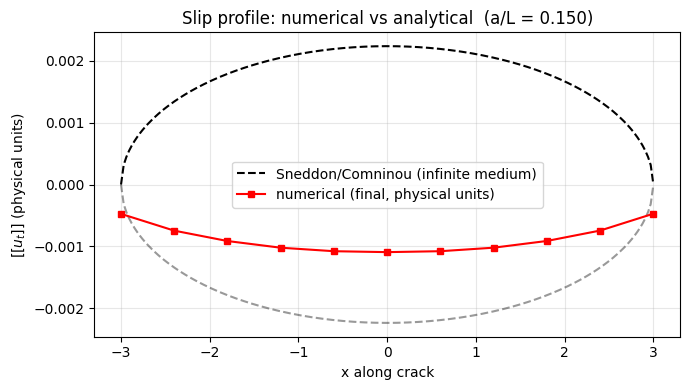

In [97]:
crack_half_length = CRACK_LENGTH / 2.0
delta_tau_mpa = abs(tau_sliding_val) - MU * sigma_N_sliding
u_t_max_analytic_phys = 2.0 * delta_tau_mpa * (1.0 - NU) * crack_half_length / G_SHEAR

# Solver state z is non-dimensional; physical displacement = z_nondim * SCALE_L * SCALE_EPS.
DISP_SCALE = SCALE_L * SCALE_EPS
num_slip_max_nondim = float(np.max(np.abs(sliding_slip)))
num_slip_max_phys = num_slip_max_nondim * DISP_SCALE

# Boundary-effect estimate: a/L. For a/L < 0.05 the infinite-medium formula
# is accurate to a few percent. For a/L = 0.2 (default 1x1 box) the
# finite-domain correction is O(20-30%).
a_over_L = crack_half_length / max(XMAX - XMIN, YMAX - YMIN, 1e-30)
if a_over_L < 0.05:
    boundary_band = "≲ 5% (infinite-medium formula essentially valid)"
elif a_over_L < 0.10:
    boundary_band = "5-15%"
elif a_over_L < 0.20:
    boundary_band = "15-30%"
else:
    boundary_band = "≳ 30% (formula gives only an order-of-magnitude target)"

x_along = np.linspace(-crack_half_length, crack_half_length, 200)
u_t_profile_analytic = (
    2.0 * delta_tau_mpa * (1.0 - NU) / G_SHEAR
    * np.sqrt(np.clip(crack_half_length ** 2 - x_along ** 2, 0.0, None))
)

print("Analytical infinite-medium plane-strain estimate:")
print(f"  half-length a               = {crack_half_length:.4f}")
print(f"  domain L                    = {XMAX - XMIN:.4f}")
print(f"  a/L                         = {a_over_L:.4f}  ({boundary_band})")
print(f"  Mohr prestress  sigma_N     = {sigma_N_sliding:.4f} MPa")
print(f"  Mohr prestress  |tau|       = {abs(tau_sliding_val):.4f} MPa")
print(f"  stress drop  Delta_tau      = {delta_tau_mpa:.4f} MPa")
print(f"  shear modulus G             = {G_SHEAR:.1f} MPa")
print(f"  Poisson ratio nu            = {NU}")
print(f"  predicted [[u_t]]_max       = {u_t_max_analytic_phys:.4e}  (physical units)")
print(f"  numerical max |[[u_t]]|     = {num_slip_max_phys:.4e}  (physical units, "
      f"applied scale {DISP_SCALE:.1e})")
ratio_phys = num_slip_max_phys / max(u_t_max_analytic_phys, 1e-30)
print(f"  ratio numerical / analytic  = {ratio_phys:.3f}")
print("  (interpretation: ratio ~ 1 if box is large enough that boundary effects vanish;\n"
      "                   < 1 means finite domain stiffer than infinite medium;\n"
      "                   > 1 means finite domain more compliant)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_along, u_t_profile_analytic, 'k--', lw=1.5,
        label='Sneddon/Comninou (infinite medium)')
ax.plot(x_along, -u_t_profile_analytic, 'k--', lw=1.5, alpha=0.4)
slip_final = np.asarray(sliding_slip[-1], dtype=float) * DISP_SCALE
node_x = np.linspace(-crack_half_length, crack_half_length, slip_final.size)
ax.plot(node_x, slip_final, 'rs-', ms=5, label='numerical (final, physical units)')
ax.set_xlabel('x along crack')
ax.set_ylabel(r'$[[u_t]]$ (physical units)')
ax.set_title(f'Slip profile: numerical vs analytical  (a/L = {a_over_L:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Analytical max slip (physical units) = 2.2346e-03  (applied scale 1.0e-03)


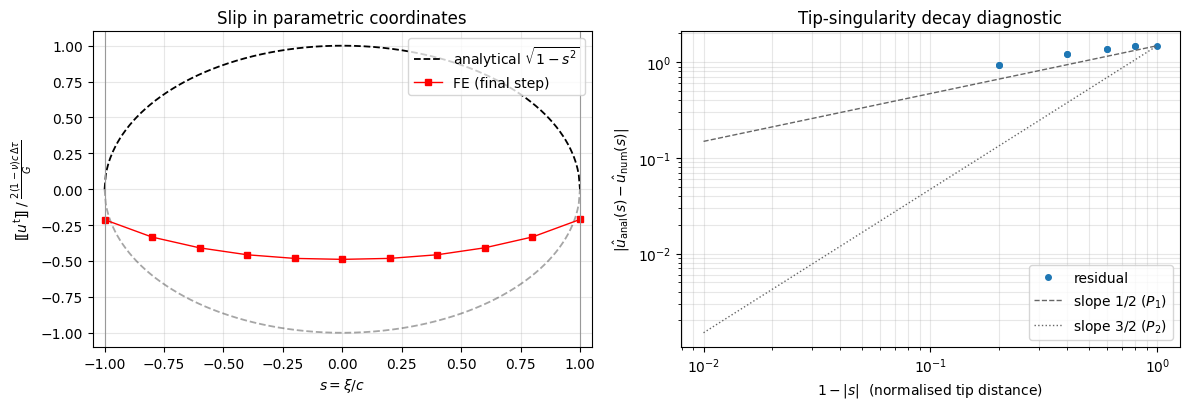

slip_max  analytical (phys) = 2.2346e-03
slip_max  FE          (phys)= -1.0918e-03   (centre, s ~ 0)
FE tip slip  |s| -> 1       = -4.7396e-04, -4.7101e-04   (should be 0 in the analytical limit)

Tip values are NOT expected to be zero in the FE solution because the
nearest jump DOF is one element-edge from the geometric tip, the
sqrt-singularity in D(xi) is unresolvable by polynomial bases, and the
finite box adds a domain correction.  The tip-decay log-log slope on
the right panel is the diagnostic: P1 elements should give slope 1/2,
P2 should give slope 3/2; departures indicate cone-tolerance noise or
BOX_SCALE-induced finite-domain bias.


In [98]:
# =============================================================================
# Sliding slip in PARAMETRIC COORDINATES s = xi / c, against the universal
# Crouch-Starfield / Pollard-Segall curve  hat_u(s) = sqrt(1 - s^2).
#
# Why parametric:
#   (a) crack-length / unit-system independent;
#   (b) the analytical target is the universal half-circle, so deviations
#       are visible by eye as deviations from a circle;
#   (c) the tip-decay diagnostic on (1 - |s|)  exposes the sqrt(r) FE
#       singularity rate cleanly: P1 -> slope 1/2,  P2 -> slope 3/2.
#
# Why FE slip does not vanish at the geometric tip:
#   - duplicated-node layer terminates one element-edge inside the tip,
#     so the smallest |s| where a jump DOF exists is 1 - h/c, not 1;
#   - the analytical D(xi) ~ 1 / sqrt(c^2 - xi^2) is unresolvable by P1/P2
#     polynomial bases (sqrt-singularity);
#   - finite-domain (BOX_SCALE) corrections shift the tip slip;
#   - Coulomb cone enforced only to nl_atol/nl_rtol.
# =============================================================================

c_half        = crack_half_length                              # crack half-length
slip_max_anal = 2.0 * delta_tau_mpa * (1.0 - NU) * c_half / G_SHEAR
DISP_SCALE    = SCALE_L * SCALE_EPS
print(f"Analytical max slip (physical units) = {slip_max_anal:.4e}  (applied scale {DISP_SCALE:.1e})")
# Numerical slip at the final time, in physical units, on the duplicated layer.
slip_phys = np.asarray(sliding_slip[-1], dtype=float) * DISP_SCALE
n_nodes   = slip_phys.size

# Tangent coordinate along the crack, normalised to s in [-1, 1].
# The duplicated-node layer is uniformly spaced over [-c_half, +c_half].
xi_phys   = np.linspace(-c_half, c_half, n_nodes)
s_param   = xi_phys / c_half

# Normalised numerical and analytical slip.
slip_norm_num   = slip_phys / slip_max_anal
slip_norm_anal  = np.sqrt(np.clip(1.0 - s_param ** 2, 0.0, None))

# --- Plot: side-by-side parametric profile + tip-decay log-log ---
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4.2))

# (1) Parametric profile
s_dense = np.linspace(-1, 1, 401)
ax_left.plot(s_dense, np.sqrt(1.0 - s_dense ** 2), 'k--', lw=1.3,
             label=r'analytical $\sqrt{1-s^2}$')
ax_left.plot(s_dense, -np.sqrt(1.0 - s_dense ** 2), 'k--', lw=1.3, alpha=0.35)
ax_left.plot(s_param, slip_norm_num, 'rs-', ms=4, lw=1.0,
             label='FE (final step)')
ax_left.set_xlabel(r'$s = \xi / c$')
ax_left.set_ylabel(r'$[\![u^{\rm t}]\!] \; / \; \frac{2(1-\nu)c\,\Delta\tau}{G}$')
ax_left.set_title('Slip in parametric coordinates')
ax_left.set_xlim(-1.05, 1.05)
ax_left.axvline(-1, color='0.6', lw=0.8); ax_left.axvline(1, color='0.6', lw=0.8)
ax_left.legend(loc='upper right')
ax_left.grid(alpha=0.3)

# (2) Tip-decay diagnostic.  At the geometric tip (|s|=1) the FE basis
# cannot represent the sqrt(c^2 - xi^2) shape; the residual decays as
# (1-|s|)^p where p depends on the element order.
tip_dist  = 1.0 - np.abs(s_param)
err       = np.abs(slip_norm_anal - slip_norm_num)
mask      = (tip_dist > 0) & (err > 0)
ax_right.loglog(tip_dist[mask], err[mask], 'o', ms=4, label='residual')

# Reference slopes for P1 (sqrt(h)) and P2 (h^{3/2}) tip convergence
ref_x = np.array([1e-2, 1.0])
ref_y_p1 = err[mask].max() * (ref_x / ref_x.max()) ** 0.5
ref_y_p2 = err[mask].max() * (ref_x / ref_x.max()) ** 1.5
ax_right.loglog(ref_x, ref_y_p1, '--', color='0.4', lw=1.0,
                label=r'slope $1/2$ ($P_1$)')
ax_right.loglog(ref_x, ref_y_p2, ':',  color='0.4', lw=1.0,
                label=r'slope $3/2$ ($P_2$)')
ax_right.set_xlabel(r'$1 - |s|$  (normalised tip distance)')
ax_right.set_ylabel(r'$|\hat u_{\rm anal}(s) - \hat u_{\rm num}(s)|$')
ax_right.set_title('Tip-singularity decay diagnostic')
ax_right.legend(loc='lower right')
ax_right.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Reporter
print(f"slip_max  analytical (phys) = {slip_max_anal:.4e}")
print(f"slip_max  FE          (phys)= {slip_phys[np.argmin(np.abs(s_param))]:.4e}"
      f"   (centre, s ~ 0)")
print(f"FE tip slip  |s| -> 1       = {slip_phys[0]:.4e}, {slip_phys[-1]:.4e}"
      f"   (should be 0 in the analytical limit)")
print()
print("Tip values are NOT expected to be zero in the FE solution because the")
print("nearest jump DOF is one element-edge from the geometric tip, the")
print("sqrt-singularity in D(xi) is unresolvable by polynomial bases, and the")
print("finite box adds a domain correction.  The tip-decay log-log slope on")
print("the right panel is the diagnostic: P1 elements should give slope 1/2,")
print("P2 should give slope 3/2; departures indicate cone-tolerance noise or")
print("BOX_SCALE-induced finite-domain bias.")


### 10c. Quasi-Static Convergence Diagnostic

For $\alpha = 0$ the steady state $\dot y = 0$ satisfies a viscosity-independent
static elastic problem.  Two checks:

1. The dynamic residual $\|{\rm rhs}(t,\,y(t))\|_\infty$ at $t_{\rm final}$
   should approach zero as the run length grows.
2. The numeric drift $\|y(t)-y(t-\Delta t)\|_\infty / \Delta t$ should decay
   monotonically. The decay timescale grows like $\tau_v \sim \eta_v / (\lambda+2\mu)$,
   but the limit point is the same for every viscosity.

If the run is in the converged regime, **changing $\eta_v$ must not change the
final slip distribution** (it only changes how long it takes to get there).


Quasi-static convergence diagnostic (sliding test):
  ||rhs(t, y(T))||_inf at t_final  = 3.851e-02
  tau_v ~ (mu_v + lam_v) / (lam + 2mu) = 5.714e-06
  TMAX / tau_v                      = 6930792.14  (OK)
  ||dy/dt||_inf along trajectory:
    t=  0.0040, ||dy/dt||_inf = 1.728e+01
    t=  2.3011, ||dy/dt||_inf = 1.442e-01
    t=  7.8757, ||dy/dt||_inf = 5.461e-02
    t= 16.4846, ||dy/dt||_inf = 2.324e-02
    t= 39.6045, ||dy/dt||_inf = 3.513e-03
  drift decay ratio (end/start)    = 2.033e-04
  (smaller is better; <<1 means QS limit is being approached)


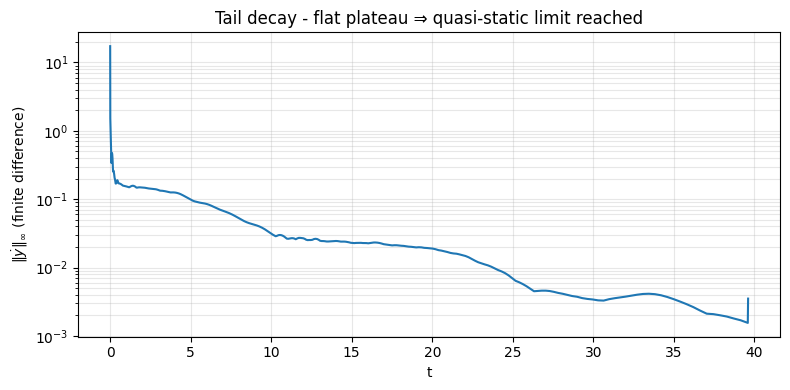

In [99]:
y_hist_s = np.asarray(y_sliding, dtype=float)
t_arr_s = np.asarray(t_sliding, dtype=float)

rhs_at_final = cs_s.rhs(t_arr_s[-1], y_hist_s[-1])
rhs_norm_final = float(np.max(np.abs(rhs_at_final)))

drift_norm = np.zeros(len(t_arr_s) - 1)
for k in range(1, len(t_arr_s)):
    dt_k = max(t_arr_s[k] - t_arr_s[k-1], 1e-30)
    drift_norm[k-1] = float(np.max(np.abs(y_hist_s[k] - y_hist_s[k-1]))) / dt_k

tau_visc = (BULK_MU_V + BULK_LAM_V) / max(LAM + 2.0 * MU_LAME, 1e-30)
tmax_over_tau = TMAX / max(tau_visc, 1e-30)
print("Quasi-static convergence diagnostic (sliding test):")
print(f"  ||rhs(t, y(T))||_inf at t_final  = {rhs_norm_final:.3e}")
print(f"  tau_v ~ (mu_v + lam_v) / (lam + 2mu) = {tau_visc:.3e}")
print(f"  TMAX / tau_v                      = {tmax_over_tau:.2f}  "
      f"({'OK' if tmax_over_tau > 5 else 'too short - run longer for QS limit'})")

n_show = 5
ind_show = np.linspace(0, len(drift_norm) - 1, n_show).astype(int)
print("  ||dy/dt||_inf along trajectory:")
for idx in ind_show:
    print(f"    t={t_arr_s[idx+1]:>8.4f}, ||dy/dt||_inf = {drift_norm[idx]:.3e}")

if drift_norm[-1] > 0 and drift_norm[0] > 0:
    decay_ratio = drift_norm[-1] / drift_norm[0]
    print(f"  drift decay ratio (end/start)    = {decay_ratio:.3e}")
    print("  (smaller is better; <<1 means QS limit is being approached)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(t_arr_s[1:], np.maximum(drift_norm, 1e-300))
ax.set_xlabel('t')
ax.set_ylabel(r'$\|\dot y\|_\infty$ (finite difference)')
ax.set_title('Tail decay - flat plateau ⇒ quasi-static limit reached')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


### 10d. Energy Balance Check

For the perturbation formulation with $\alpha = 0$ and roller BCs, the bulk power
identity reads
$$\frac{d}{dt}\bigl(\text{KE} + U_\text{el}\bigr) + D_\text{vis,rate}
   = \bigl(B\,r_\text{total}\bigr)\cdot v,$$
where $D_\text{vis,rate} = v^\top C\,v$ is the bulk Kelvin-Voigt dissipation rate
and the right-hand side is the power exerted by the contact reactions on the
bulk velocity.  Integrating gives
$$\text{KE}(t) + U_\text{el}(t) + D_\text{vis}(t) - W_\text{contact}(t) \approx 0.$$

A **growing** residual is a numerical-conservation diagnostic: at fixed material
parameters, larger residual at higher viscosity points to under-resolved
time-stepping (e.g. controller skipping the contact block, $h_{\max}$ too large).


Energy balance (sliding test):
  final KE                       = 1.395e-04   (≈ 0 expected at QS)
  final W_el                     = 1.811e-01   (cumulative bulk elastic work)
  final D_vis                    = 2.078e-01   (bulk viscous dissipation)
  final D_fric (phys)            = 7.916e-01   (Coulomb interface dissipation)

  final W_contact     (r_total)  = -7.916e-01   (sum of pert + offset)
  final W_contact_pert(r_pert )  = 3.891e-01   (what BULK eqn integrates)
  final W_offset_external        = -1.181e+00   (prestress reservoir)

  Bulk identity (rigorous, uses r_pert)         : 8.291e-05   (rel: 2.131e-04)
    KE + W_el + D_vis − W_contact_pert ≈ 0
  Bulk identity (loose, uses r_total)           : 1.181e+00   (rel: 1.491e+00)
    KE + W_el + D_vis − W_contact_total ≈ 0  (off by W_offset_external)
  Interface identity (Coulomb, r_total)         : 2.685e-11   (rel: 3.392e-11)
    D_fric + W_contact_total ≈ 0
  Algebraic consistency W_total = W_pert + W_off: 1.221e-15   (rel: 

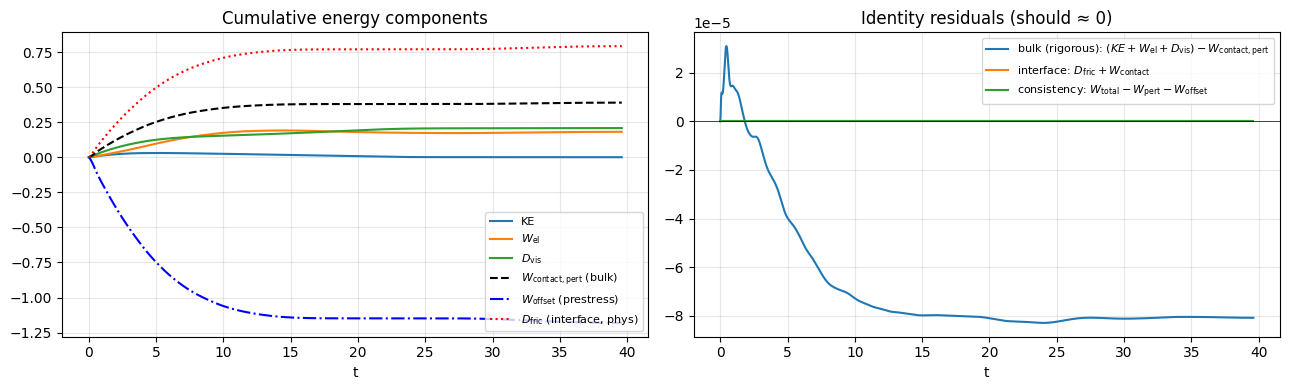

In [100]:
# ── Operators in the descriptor frame ──────────────────────────────────────
J0 = rhs_jac_dyn_s_eff(0.0, np.zeros(A_dyn_s.shape[0])).tocsr()
A0 = A_dyn_s.tocsr()

mom_rows  = slice(n_base_s, n_phys_sliding)
base_cols = slice(0, n_base_s)
vel_cols  = slice(n_base_s, n_phys_sliding)

# All extracted from the descriptor Jacobian / mass; signs match the
# convention   M v̇ = -K z - C v + B r  +  prestress.
K_op = -(J0[mom_rows, :][:, base_cols]).tocsr()   # rotated-frame stiffness
C_op = -(J0[mom_rows, :][:, vel_cols]).tocsr()    # viscous tangent
M_op = (A0[mom_rows, :][:, vel_cols]).tocsr()     # FE mass

# ── State histories ─────────────────────────────────────────────────────────
z_hist      = y_hist_s[:, :n_base_s]
v_hist      = y_hist_s[:, n_base_s:n_phys_sliding]
r_pert_hist = y_hist_s[:, n_phys_sliding:]
sigma_offset_nondim = _contact_offset_vector(_s0_val_s, _w0_val_s)
r_total_hist = r_pert_hist + sigma_offset_nondim[None, :]

B_vel = B_c_dyn_s[n_base_s:n_phys_sliding, :].tocsr()

# Interface weights ω_k per contact node (the lumped FE measure)
omega_node = np.asarray(omega_n_s if 'omega_n_s' in globals() else omega_n, dtype=float)

# r_pert is interleaved [r_n_0, r_t_0, r_n_1, r_t_1, …]
r_n_pert_hist = r_pert_hist[:, 0::2]
r_t_pert_hist = r_pert_hist[:, 1::2]
r_n_total_hist_nd = r_n_pert_hist + _s0_val_s[None, :]
r_t_total_hist_nd = r_t_pert_hist + _w0_val_s[None, :]

# ── Storage convention: r_stored ≡ [[λ_σ]] = 2 · r_phys ────────────────────
# Per the variational two-sided trace:
#       [[σ]]·n̂ = 2 {{t̂}}      (jump of σ·n̂ equals twice the avg phys traction)
# The Coulomb cone is scale-invariant, so r_stored is consistent for the
# constraint, but for an explicit interface dissipation in physical units
# we apply r_phys = (1/2) r_stored.
HALF_PHYS = 0.5

# ── Per-step instantaneous power rates (nondim) ────────────────────────────
n_steps = len(t_arr_s)
KE          = np.zeros(n_steps)
P_elastic   = np.zeros(n_steps)   # rate of bulk elastic work: v · K_op · z
D_vis_rate  = np.zeros(n_steps)
P_contact         = np.zeros(n_steps)   # uses r_total (offset + pert)
P_contact_pert    = np.zeros(n_steps)   # uses r_pert  (what bulk actually sees in rhs)
P_offset_external = np.zeros(n_steps)   # uses constant sigma_offset (prestress reservoir)
D_fric_rate       = np.zeros(n_steps)
B_vel_offset = (B_vel @ sigma_offset_nondim)  # constant in time

sliding_vt_arr = np.asarray(sliding_vt, dtype=float)

for k in range(n_steps):
    z_k = z_hist[k]
    v_k = v_hist[k]
    KE[k]          = 0.5 * float(v_k @ (M_op @ v_k))
    P_elastic[k]   = float(v_k @ (K_op @ z_k))
    D_vis_rate[k]  = float(v_k @ (C_op @ v_k))
    P_contact[k]   = float(v_k @ (B_vel @ r_total_hist[k]))
    P_contact_pert[k]    = float(v_k @ (B_vel @ r_pert_hist[k]))
    P_offset_external[k] = float(v_k @ B_vel_offset)
    sigma_N_phys_nd = HALF_PHYS * np.maximum(r_n_total_hist_nd[k], 0.0)
    D_fric_rate[k] = float(np.sum(MU * sigma_N_phys_nd * np.abs(sliding_vt_arr[k]) * omega_node))

# ── Cumulative integrals (trapezoidal) ──────────────────────────────────────
W_el              = np.zeros(n_steps)   # ∫ v · K_op z dτ  (bulk elastic work)
D_vis_int         = np.zeros(n_steps)
W_contact         = np.zeros(n_steps)   # ∫ v · B · r_total dτ
W_contact_pert    = np.zeros(n_steps)   # ∫ v · B · r_pert  dτ  (what bulk eqn integrates)
W_offset_external = np.zeros(n_steps)   # ∫ v · B · σ_offset dτ (prestress reservoir)
D_fric_int        = np.zeros(n_steps)
for k in range(1, n_steps):
    dt_k = t_arr_s[k] - t_arr_s[k-1]
    W_el[k]       = W_el[k-1]       + 0.5 * (P_elastic[k]   + P_elastic[k-1])   * dt_k
    D_vis_int[k]  = D_vis_int[k-1]  + 0.5 * (D_vis_rate[k]  + D_vis_rate[k-1])  * dt_k
    W_contact[k]  = W_contact[k-1]  + 0.5 * (P_contact[k]   + P_contact[k-1])   * dt_k
    W_contact_pert[k]    = W_contact_pert[k-1]    + 0.5 * (P_contact_pert[k]    + P_contact_pert[k-1])    * dt_k
    W_offset_external[k] = W_offset_external[k-1] + 0.5 * (P_offset_external[k] + P_offset_external[k-1]) * dt_k
    D_fric_int[k] = D_fric_int[k-1] + 0.5 * (D_fric_rate[k] + D_fric_rate[k-1]) * dt_k

# ── Identities ─────────────────────────────────────────────────────────────
# Bulk power balance (exact in continuous time, descriptor frame):
#     d(KE)/dt = -P_elastic - D_vis_rate + P_contact
#     ⇒  KE(t) + W_el(t) + D_vis(t) - W_contact(t) ≈ 0
#
# Interface Coulomb identity (cone-active, per-area physical units):
#     D_fric(t) + W_contact(t) ≈ 0
# Rigorous bulk identity: bulk only sees B·r_pert in its rhs
res_bulk_pert  = (KE + W_el + D_vis_int) - W_contact_pert
# "Loose" form using r_total (mixes interface friction + offset reservoir)
res_bulk_total = (KE + W_el + D_vis_int) - W_contact
# Interface (Coulomb at active sliding, total reaction)
res_interface  = D_fric_int + W_contact
# Consistency (algebra): W_contact_total = W_contact_pert + W_offset_external
res_consistency = W_contact - (W_contact_pert + W_offset_external)

peak_w_total = max(float(np.max(np.abs(W_contact))), 1e-30)
peak_w_pert  = max(float(np.max(np.abs(W_contact_pert))), 1e-30)
peak_w_off   = max(float(np.max(np.abs(W_offset_external))), 1e-30)
peak_res_bulk_pert  = float(np.max(np.abs(res_bulk_pert)))
peak_res_bulk_total = float(np.max(np.abs(res_bulk_total)))
peak_res_int        = float(np.max(np.abs(res_interface)))
peak_res_consist    = float(np.max(np.abs(res_consistency)))

print("Energy balance (sliding test):")
print(f"  final KE                       = {KE[-1]:.3e}   (≈ 0 expected at QS)")
print(f"  final W_el                     = {W_el[-1]:.3e}   (cumulative bulk elastic work)")
print(f"  final D_vis                    = {D_vis_int[-1]:.3e}   (bulk viscous dissipation)")
print(f"  final D_fric (phys)            = {D_fric_int[-1]:.3e}   (Coulomb interface dissipation)")
print()
print(f"  final W_contact     (r_total)  = {W_contact[-1]:.3e}   (sum of pert + offset)")
print(f"  final W_contact_pert(r_pert )  = {W_contact_pert[-1]:.3e}   (what BULK eqn integrates)")
print(f"  final W_offset_external        = {W_offset_external[-1]:.3e}   (prestress reservoir)")
print()
print(f"  Bulk identity (rigorous, uses r_pert)         : {peak_res_bulk_pert:.3e}   (rel: {peak_res_bulk_pert/peak_w_pert:.3e})")
print(f"    KE + W_el + D_vis − W_contact_pert ≈ 0")
print(f"  Bulk identity (loose, uses r_total)           : {peak_res_bulk_total:.3e}   (rel: {peak_res_bulk_total/peak_w_total:.3e})")
print(f"    KE + W_el + D_vis − W_contact_total ≈ 0  (off by W_offset_external)")
print(f"  Interface identity (Coulomb, r_total)         : {peak_res_int:.3e}   (rel: {peak_res_int/peak_w_total:.3e})")
print(f"    D_fric + W_contact_total ≈ 0")
print(f"  Algebraic consistency W_total = W_pert + W_off: {peak_res_consist:.3e}   (rel: {peak_res_consist/peak_w_total:.3e})")
print()
print(f"  Interpretation:")
print(f"    The OFFSET (s0,w0 outside cone) is the prestress reservoir that drives slip.")
print(f"    It enters only the cone constraint, NOT the bulk rhs directly.")
print(f"    Bulk identity uses r_pert (rigorous); interface identity uses r_total.")
print(f"    Energy flow: W_offset_external → cone-projected r_pert → bulk dynamics → friction.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(t_arr_s, KE, label='KE')
axes[0].plot(t_arr_s, W_el, label=r'$W_\mathrm{el}$')
axes[0].plot(t_arr_s, D_vis_int, label=r'$D_\mathrm{vis}$')
axes[0].plot(t_arr_s, W_contact_pert, ls='--', color='black',
             label=r'$W_\mathrm{contact, pert}$ (bulk)')
axes[0].plot(t_arr_s, W_offset_external, ls='-.', color='blue',
             label=r'$W_\mathrm{offset}$ (prestress)')
axes[0].plot(t_arr_s, D_fric_int, ls=':', color='red',
             label=r'$D_\mathrm{fric}$ (interface, phys)')
axes[0].set_xlabel('t')
axes[0].set_title('Cumulative energy components')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].plot(t_arr_s, res_bulk_pert,
             label=r'bulk (rigorous): $(KE+W_\mathrm{el}+D_\mathrm{vis}) - W_\mathrm{contact, pert}$')
axes[1].plot(t_arr_s, res_interface,
             label=r'interface: $D_\mathrm{fric} + W_\mathrm{contact}$')
axes[1].plot(t_arr_s, res_consistency,
             label=r'consistency: $W_\mathrm{total} - W_\mathrm{pert} - W_\mathrm{offset}$')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('t')
axes[1].set_title('Identity residuals (should ≈ 0)')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


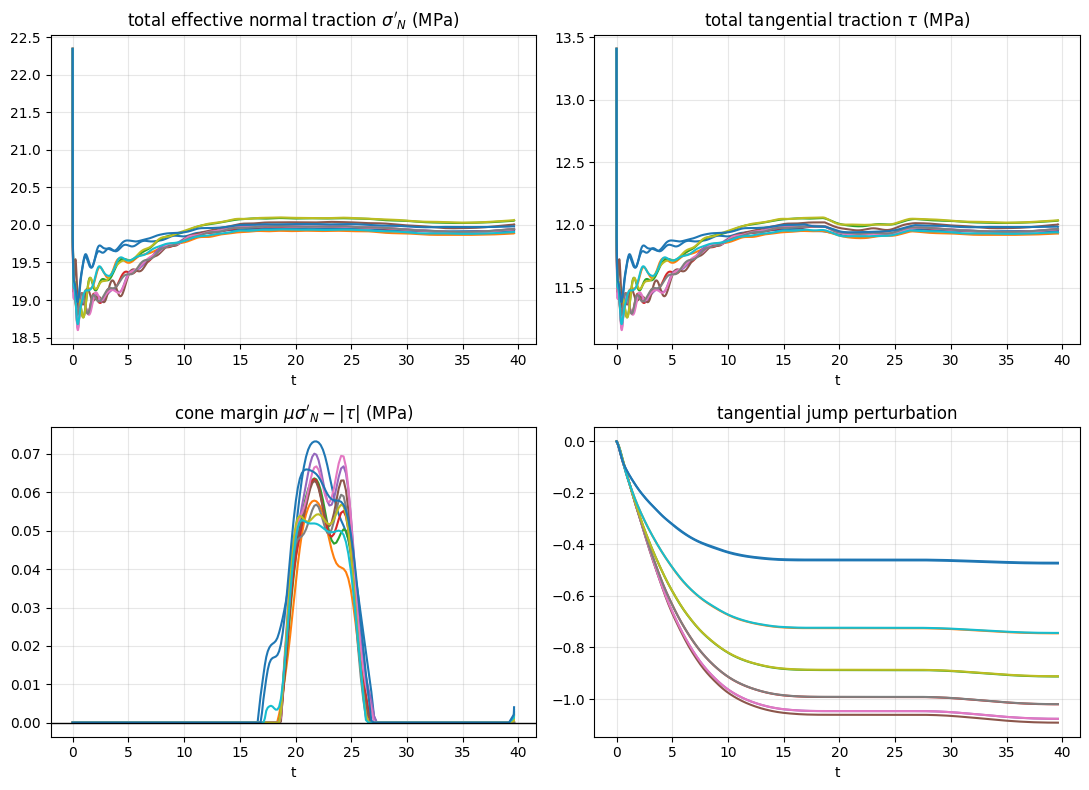

final min cone margin MPa -1.971756091734278e-13
final max |cone margin| MPa 0.004017026400646273


In [101]:

# Plot sliding response in physical total effective traction units.
r_n = r_n_sliding
r_t = r_t_sliding
cone_margin = sliding_cone_margin

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0,0].plot(t_sliding, r_n)
axes[0,0].set_title(r"total effective normal traction $\sigma'_N$ (MPa)")
axes[0,0].set_xlabel('t')
axes[0,0].grid(True, alpha=0.3)
axes[0,1].plot(t_sliding, r_t)
axes[0,1].set_title(r"total tangential traction $\tau$ (MPa)")
axes[0,1].set_xlabel('t')
axes[0,1].grid(True, alpha=0.3)
axes[1,0].plot(t_sliding, cone_margin)
axes[1,0].axhline(0, color='k', lw=1)
axes[1,0].set_title(r"cone margin $\mu\sigma'_N-|\tau|$ (MPa)")
axes[1,0].set_xlabel('t')
axes[1,0].grid(True, alpha=0.3)
axes[1,1].plot(t_sliding, sliding_slip)
axes[1,1].set_title(r"tangential jump perturbation")
axes[1,1].set_xlabel('t')
axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("final min cone margin MPa", cone_margin[-1].min())
print("final max |cone margin| MPa", np.max(np.abs(cone_margin[-1])))


### 10aa. Total-stress smoothness across the crack

Variational identity check (rotated nt frame, avg/jmp transform): $[[\sigma_\mathrm{tot}\!\cdot\!n]]$ should be $\approx 0$ (no jump in *total* bulk traction across the crack), and the average $\{\!\{\sigma_\mathrm{tot}\!\cdot\!n\}\!\}$ should equal $\pm R$ (contact reaction). The *effective* traction does jump by $\alpha[[p]]\,n$ via the Biot decomposition — that's separate.


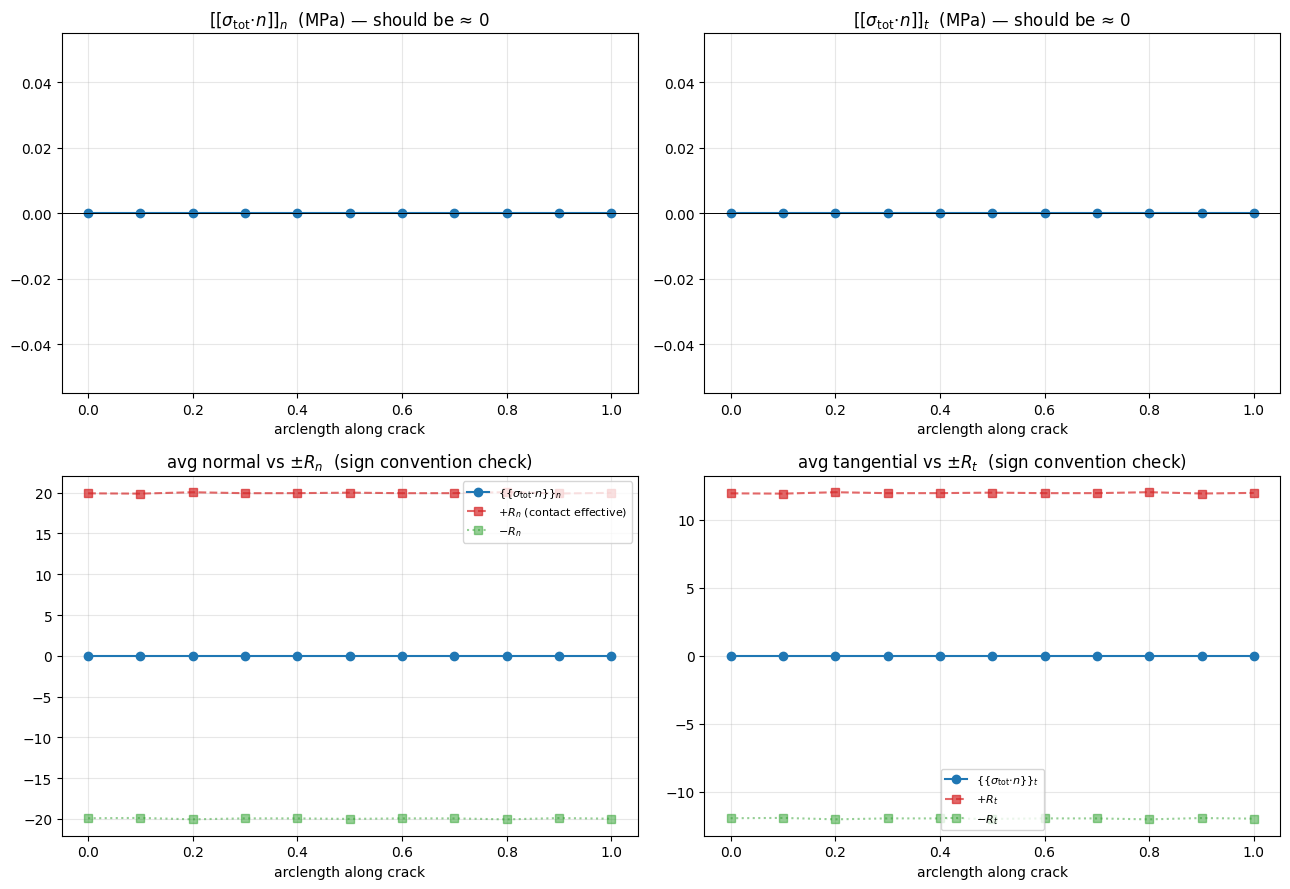

Total-stress smoothness verification (final time):
  max |[[σ_tot·n]]_n|        = 0.000e+00 MPa
  max |[[σ_tot·n]]_t|        = 0.000e+00 MPa
  max |{{σ_tot·n}}_n − R_n|    = 2.007e+01 MPa
  max |{{σ_tot·n}}_n + R_n|    = 2.007e+01 MPa  (whichever is small ⇒ that's the sign convention)
  max |{{σ_tot·n}}_t − R_t|    = 1.204e+01 MPa
  max |{{σ_tot·n}}_t + R_t|    = 1.204e+01 MPa


In [102]:
# === 10aa. Total-stress smoothness across the crack =========================
# Sanity check on the variational form (rotated nt frame, avg/jmp transform).
# IBP at the interface gives:
#     {v}-coefficient   →   [[σ_tot · n]] = 0     (smoothness, no jump)
#     [[v]]-coefficient →   {{σ_tot · n}} = ±R    (avg balanced by contact reaction)
# The first identity says the *total* bulk traction does NOT jump across the
# crack, even though [[σ' · n]] = R + α[[p]] · n DOES jump (Biot decomposition).
# This cell extracts both components from y_sliding and verifies the identities.

info_st = poro_s._transform_info
off_avgls_s = info_st.get('off_avgls', None)
off_jmpls_s = info_st['off_jmpls']

y_final_s = np.asarray(y_sliding[-1], dtype=float)

# Layout (rotated_to_nt + avg/jmp): per-direction-grouped, n then t.
# Each block has n_c_s entries = one value per crack node.
jmp_sigma_n_nondim = y_final_s[off_jmpls_s + 0          : off_jmpls_s + n_c_s    ]
jmp_sigma_t_nondim = y_final_s[off_jmpls_s + n_c_s      : off_jmpls_s + 2 * n_c_s]
jmp_sigma_n_MPa = jmp_sigma_n_nondim * Sigma_scale
jmp_sigma_t_MPa = jmp_sigma_t_nondim * Sigma_scale

if off_avgls_s is not None:
    avg_sigma_n_nondim = y_final_s[off_avgls_s + 0          : off_avgls_s + n_c_s    ]
    avg_sigma_t_nondim = y_final_s[off_avgls_s + n_c_s      : off_avgls_s + 2 * n_c_s]
    avg_sigma_n_MPa = avg_sigma_n_nondim * Sigma_scale
    avg_sigma_t_MPa = avg_sigma_t_nondim * Sigma_scale
else:
    avg_sigma_n_MPa = avg_sigma_t_MPa = None

# Contact reaction at final time (effective traction, in rotated nt frame, per node)
r_pert_final = y_final_s[n_phys_s : n_phys_s + 2 * n_c_s]
offset_final = np.zeros(2 * n_c_s)
offset_final[0::2] = _s0_val_s
offset_final[1::2] = _w0_val_s
r_total_final_nondim = r_pert_final + offset_final
R_n_MPa = r_total_final_nondim[0::2] * Sigma_scale
R_t_MPa = r_total_final_nondim[1::2] * Sigma_scale

# Crack-arclength coordinate (parametric: 0..1 along the crack)
s_param = np.linspace(0.0, 1.0, n_c_s)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(s_param, jmp_sigma_n_MPa, 'o-', color='C0')
axes[0, 0].axhline(0, color='k', lw=0.7)
axes[0, 0].set_title(r'$[[\sigma_\mathrm{tot}\!\cdot\!n]]_n$  (MPa) — should be ≈ 0')
axes[0, 0].set_xlabel('arclength along crack')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(s_param, jmp_sigma_t_MPa, 'o-', color='C0')
axes[0, 1].axhline(0, color='k', lw=0.7)
axes[0, 1].set_title(r'$[[\sigma_\mathrm{tot}\!\cdot\!n]]_t$  (MPa) — should be ≈ 0')
axes[0, 1].set_xlabel('arclength along crack')
axes[0, 1].grid(alpha=0.3)

if avg_sigma_n_MPa is not None:
    axes[1, 0].plot(s_param,  avg_sigma_n_MPa, 'o-', color='C0',
                    label=r'$\{\{\sigma_\mathrm{tot}\!\cdot\!n\}\}_n$')
    axes[1, 0].plot(s_param,  R_n_MPa,         's--', color='C3', alpha=0.7,
                    label=r'$+R_n$ (contact effective)')
    axes[1, 0].plot(s_param, -R_n_MPa,         's:',  color='C2', alpha=0.5,
                    label=r'$-R_n$')
else:
    axes[1, 0].plot(s_param, R_n_MPa, 's-', label=r'$R_n$ (contact)')
axes[1, 0].set_title(r'avg normal vs $\pm R_n$  (sign convention check)')
axes[1, 0].set_xlabel('arclength along crack')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

if avg_sigma_t_MPa is not None:
    axes[1, 1].plot(s_param,  avg_sigma_t_MPa, 'o-', color='C0',
                    label=r'$\{\{\sigma_\mathrm{tot}\!\cdot\!n\}\}_t$')
    axes[1, 1].plot(s_param,  R_t_MPa,         's--', color='C3', alpha=0.7,
                    label=r'$+R_t$')
    axes[1, 1].plot(s_param, -R_t_MPa,         's:',  color='C2', alpha=0.5,
                    label=r'$-R_t$')
else:
    axes[1, 1].plot(s_param, R_t_MPa, 's-', label=r'$R_t$ (contact)')
axes[1, 1].set_title(r'avg tangential vs $\pm R_t$  (sign convention check)')
axes[1, 1].set_xlabel('arclength along crack')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Total-stress smoothness verification (final time):")
print(f"  max |[[σ_tot·n]]_n|        = {np.max(np.abs(jmp_sigma_n_MPa)):.3e} MPa")
print(f"  max |[[σ_tot·n]]_t|        = {np.max(np.abs(jmp_sigma_t_MPa)):.3e} MPa")
if avg_sigma_n_MPa is not None:
    res_pos_n = np.max(np.abs(avg_sigma_n_MPa - R_n_MPa))
    res_neg_n = np.max(np.abs(avg_sigma_n_MPa + R_n_MPa))
    res_pos_t = np.max(np.abs(avg_sigma_t_MPa - R_t_MPa))
    res_neg_t = np.max(np.abs(avg_sigma_t_MPa + R_t_MPa))
    print(f"  max |{{{{σ_tot·n}}}}_n − R_n|    = {res_pos_n:.3e} MPa")
    print(f"  max |{{{{σ_tot·n}}}}_n + R_n|    = {res_neg_n:.3e} MPa  (whichever is small ⇒ that's the sign convention)")
    print(f"  max |{{{{σ_tot·n}}}}_t − R_t|    = {res_pos_t:.3e} MPa")
    print(f"  max |{{{{σ_tot·n}}}}_t + R_t|    = {res_neg_t:.3e} MPa")


### 10a. Dashboard — Sliding

Full-field perturbation contours.  Expect visible displacement discontinuity at the crack
and stress redistribution near the crack tips.

In [103]:
z_sliding = y_sliding[:, :n_base_s]

fields_sliding = poro_s.sol_to_fields_dict_with_dimensions(
    np.asarray(t_sliding),
    z_sliding.T,
    use_taylor_correction=False,
    constrained_l2=False,
)
fields_sliding['y_raw'] = z_sliding.T
fields_sliding['t_raw'] = np.asarray(t_sliding)

dashboard_sliding = CGPoroelasticDashboard(poro_s, fields_sliding, levels=40)
dashboard_sliding.show()

## 10e. Slip-Weakening Friction Extension

Replace constant μ on the sliding crack by a slip-weakening law:

$$
\mu(s) = \mu_\mathrm{res}\Bigl(1 - \frac{\Delta\mu}{\mu_\mathrm{res}}\,e^{-s_\mathrm{eff}/D_c}\Bigr),
\qquad s_\mathrm{eff} = \max(s, 0),
\qquad \dot s = \lvert [[v_t]]\rvert.
$$

With $\Delta\mu = \mu_\mathrm{res} - \mu_\mathrm{static} = -0.1$ and $\mu_\mathrm{res}=0.5$,
$\mu_\mathrm{static} = 0.6$ and friction monotonically weakens to $\mu_\mathrm{res}$ over
the characteristic slip $D_c = 0.10\,\mathrm{mm}$. Cumulative slip $s$ is added as a new
ODE state per contact node — one extra DOF each, with $\dot s = |[[v_t]]| \ge 0$ enforcing
no healing without any explicit clamp.

**Stability criterion (Ruina/Rice).** Linearised stability of the QS branch requires
$G/D > -\Delta\mu\,\sigma_N/D_c$. When violated, $|[[u_t]]|$ runs away to the stress-drop
seismic slip $\Delta\tau\,D/G = -\Delta\mu\,\sigma_N\,D/G$.


In [49]:
# === Slip-weakening config and validation diagnostics ====================
# Slip-weakening parameterised by (μ_static, μ_res):
#   DMU_SW = μ_res − μ_static  (≤ 0 weakens, 0 ⇒ pure Coulomb at μ_static).
# Set MU_RES_SW = MU_STATIC_SW for pure Coulomb; MU_RES_SW = 0.5 for weakening.
MU_STATIC_SW = 0.6                                   # peak (≡ global MU)
MU_RES_SW    = 0.5                                   # residual (set 0.5 for weakening)
DMU_SW       = MU_RES_SW - MU_STATIC_SW              # auto: 0 here, −0.1 if μ_res=0.5
DC_PHYS_SW   = 0.10 / 1000.0                         # m  (0.10 mm)
DC_NONDIM_SW = DC_PHYS_SW / DISP_SCALE               # state is non-dim displacement

print(f"Slip-weakening: mu_static={MU_STATIC_SW}, mu_res={MU_RES_SW}, "
      f"Dmu={DMU_SW:+}")
print(f"  Dc_phys = {DC_PHYS_SW:.3e} m,   Dc_nondim = {DC_NONDIM_SW:.3e}")

# --- Stability + seismic-slip estimates (user pseudo-solution) ----------
G_phys_sw     = G_SHEAR
D_len_sw      = CRACK_LENGTH                                    # crack length [m]
L_len_sw      = max(XMAX - XMIN, YMAX - YMIN, 1e-30)            # domain length [m]
sigma_N_eff_0 = sigma_N_sliding                                 # MPa, far-field

print(f"  G/(D/L)        = {G_phys_sw / (D_len_sw / L_len_sw):.3e}",
      f"  -Dmu*sigma_N/Dc = {-DMU_SW * sigma_N_eff_0 / DC_PHYS_SW:.3e}  [units mismatch: see below]")

# Dimensionally clean form: G/D (MPa/m) vs -Δμ σ_N / Dc (MPa/m)
loading_stiffness_per_m  = G_phys_sw / D_len_sw
weakening_rate_per_m     = -DMU_SW * sigma_N_eff_0 / DC_PHYS_SW
stable_qs                = loading_stiffness_per_m > weakening_rate_per_m
print(f"  loading G/D    = {loading_stiffness_per_m:.3e} MPa/m")
print(f"  -Dmu sigma_N/Dc= {weakening_rate_per_m:.3e} MPa/m")
print(f"  QS-stable: {stable_qs}")

EQslip = -G_phys_sw / (D_len_sw / L_len_sw) > DMU_SW * sigma_N_eff_0 / DC_PHYS_SW
print(f"  EQ-like slip predicted (user form): {EQslip}")

expd_slip_per_L = -DMU_SW * sigma_N_eff_0 / G_phys_sw * D_len_sw / L_len_sw
expd_slip_phys  = expd_slip_per_L * L_len_sw           # = -Dmu * sigma_N * D / G  [m]
print(f"  Expected stress-drop seismic slip [m] (-Dmu sigma_N D / G): {expd_slip_phys:.3e}")

# === State augmentation: append cumulative slip s_k per contact node =====
n_phys_old_sw = n_phys_s
n_aug_sw      = n_phys_old_sw + n_c_s

A_aug_sw = sp.block_diag(
    [A_dyn_s, sp.eye(n_c_s, format='csr')], format='csr',
)

# v_t extraction: rows n_c..2n_c of vel_extract_dyn_s pick [[v_t]] (grouped order).
vel_t_extract_sw = vel_extract_dyn_s[n_c_s:2 * n_c_s, :].tocsr()

def rhs_sw(t, y, *extra):
    y_phys = y[:n_phys_old_sw]
    out = np.zeros(n_aug_sw)
    out[:n_phys_old_sw] = rhs_dyn_s_eff(t, y_phys)
    out[n_phys_old_sw:] = np.abs(vel_t_extract_sw @ y_phys)
    return out

def rhs_jac_sw(t, y, *extra):
    y_phys = y[:n_phys_old_sw]
    J_phys = rhs_jac_dyn_s_eff(t, y_phys)
    if not sp.issparse(J_phys):
        J_phys = sp.csr_matrix(J_phys)
    v_t = vel_t_extract_sw @ y_phys
    J_slip = sp.diags(np.sign(v_t)) @ vel_t_extract_sw
    return sp.bmat(
        [[J_phys,                                sp.csr_matrix((n_phys_old_sw, n_c_s))],
         [J_slip,                                sp.csr_matrix((n_c_s,        n_c_s))]],
        format='csr',
    )

# --- Pad contact wiring with zero columns/rows for the new slip block ---
gap_extract_sw = sp.hstack(
    [gap_extract_dyn_s, sp.csr_matrix((gap_extract_dyn_s.shape[0], n_c_s))],
    format='csr',
)
vel_extract_sw = sp.hstack(
    [vel_extract_dyn_s, sp.csr_matrix((vel_extract_dyn_s.shape[0], n_c_s))],
    format='csr',
)
B_c_sw = sp.vstack(
    [B_c_dyn_s, sp.csr_matrix((n_c_s, B_c_dyn_s.shape[1]))],
    format='csr',
)

# --- Per-contact slip-weakening mu + analytical dmu/dy ------------------
def _make_mu_sw(k):
    idx = n_phys_old_sw + k
    def _mu(y, t=None, Fk_val=None):
        s_k = float(y[idx])
        s_eff = s_k if s_k > 0.0 else 0.0
        return MU_RES_SW * (1.0 - (DMU_SW / MU_RES_SW) * np.exp(-s_eff / DC_NONDIM_SW))
    return _mu

def _make_dmu_dy_sw(k):
    idx = n_phys_old_sw + k
    def _dmu(y, t=None, Fk_val=None):
        out = np.zeros(n_aug_sw)
        s_k = float(y[idx])
        if s_k > 0.0:
            out[idx] = (DMU_SW / DC_NONDIM_SW) * np.exp(-s_k / DC_NONDIM_SW)
        return out
    return _dmu

contacts_sw = [
    {
        'vel_normal_idx': k,
        'vel_tangential_idx': [n_c_s + k],
        'mu':     _make_mu_sw(k),
        'dmu_dy': _make_dmu_dy_sw(k),
        'e': 0.0,
    }
    for k in range(n_c_s)
]

cs_sw = build_projected_radau_contact(
    A_aug_sw, rhs_sw, np.zeros(n_aug_sw),
    contacts=contacts_sw,
    C_extract=gap_extract_sw,
    D_extract=vel_extract_sw,
    B=B_c_sw,
    constraints=[flux_constraint_s, zero_lam_s_s],
    component_slices=list(comp_slices_s) + [slice(n_phys_old_sw, n_aug_sw)],
    rhs_jac=rhs_jac_sw,
    get_s0=get_s0_sliding, get_w0=get_w0_sliding,
    normal_r='auto', friction_r='auto',
    endpoint_inactive_handling='natural_map',
    contact_law=CONTACT_LAW,
    reported_reaction_units='force',
    auto_rho_strategy='delassus',
)
print(f"slip-weakening contact system: A={cs_sw.A.shape}, |y0|={cs_sw.y0.size}, "
      f"slip block at [{n_phys_old_sw}:{n_aug_sw}]")


Slip-weakening: mu_static=0.6, mu_res=0.5, Dmu=-0.09999999999999998
  Dc_phys = 1.000e-04 m,   Dc_nondim = 1.000e-01
  G/(D/L)        = 1.667e+04   -Dmu*sigma_N/Dc = 2.000e+04  [units mismatch: see below]
  loading G/D    = 1.667e+03 MPa/m
  -Dmu sigma_N/Dc= 2.000e+04 MPa/m
  QS-stable: False
  EQ-like slip predicted (user form): True
  Expected stress-drop seismic slip [m] (-Dmu sigma_N D / G): 1.200e-03
slip-weakening contact system: A=(7184, 7184), |y0|=7184, slip block at [7151:7162]


In [50]:
# === Solve slip-weakening sliding test ===================================
n_aug_total_sw = cs_sw.y0.size
nl_atol_sw = np.full(n_aug_total_sw, 1e-8)
nl_rtol_sw = np.full(n_aug_total_sw, 1e-6)
# Slip block: tight ODE tolerance, no relative scaling
nl_atol_sw[n_phys_old_sw:n_aug_sw] = 1e-10
nl_rtol_sw[n_phys_old_sw:n_aug_sw] = 0.0
# Reaction block: as in the const-mu sliding solve
nl_atol_sw[n_aug_sw:] = 1e-10
nl_rtol_sw[n_aug_sw:] = 0.0

solver_opts_sw = dict(cs_sw.solver_opts)
solver_opts_sw.update(
    tol=1e-8, max_iter=500, rhs_jac=cs_sw.rhs_jac,
    linear_solver='petsc',
    petsc_options={'ksp_type': 'preonly', 'pc_type': 'lu',
                   'pc_factor_mat_solver_type': 'mumps'},
)
integrator_opts_sw = dict(cs_sw.integrator_opts)
integrator_opts_sw.update({'stages': 2, 'use_coupled_newton': True})

print(f"Solving slip-weakening sliding: tmax={TMAX}, h0={H0_ADAPTIVE}, "
      f"contact_law={CONTACT_LAW!r}")

# Warm-start contact reactions onto the Coulomb cone (μ_static at t=0).
y0_sw_init = cs_sw.y0.copy()
y0_sw_init[-2 * n_c_s:] = coulomb_cone_warm_start(_s0_val_s, _w0_val_s, MU_STATIC_SW)

(t_sw, y_sw, h_sw, fk_sw, info_sw, attempts_sw) = solve_nivp.solve_ivp_ns(
    fun=cs_sw.rhs, t_span=(0, TMAX), y0=y0_sw_init,
    method='radau_iia', integrator_opts=integrator_opts_sw,
    projection=cs_sw.projection, solver='semismooth_newton',
    projection_opts={'component_slices': cs_sw.component_slices},
    solver_opts=solver_opts_sw,
    adaptive=True, h0=H0_ADAPTIVE, rtol=ADAPTIVE_RTOL, atol=ADAPTIVE_ATOL,
    skip_error_indices=[0], active_set_filter=False, return_attempts=True,
    adaptive_opts=dict(h0=H0_ADAPTIVE, h_min=ADAPTIVE_H_MIN,
                       h_max=ADAPTIVE_H_MAX, h_up=2.0, h_down=0.5,
                       method_order=1),
    nl_atol=nl_atol_sw, nl_rtol=nl_rtol_sw,
    component_slices=cs_sw.component_slices,
    verbose=True, A=cs_sw.A, dae_var_weight='auto',
)
t_sw = np.asarray(t_sw, dtype=float)
y_sw = np.asarray(y_sw, dtype=float)

# --- Post-process: slip, jump, effective mu -----------------------------
slip_state_sw   = y_sw[:, n_phys_old_sw:n_aug_sw]                # cumulative s_k(t)
sliding_jump_sw = y_sw[:, jmpu_t_idx_s]                          # signed [[u_t]]
mu_eff_sw = MU_RES_SW * (
    1.0 - (DMU_SW / MU_RES_SW)
    * np.exp(-np.maximum(slip_state_sw, 0.0) / DC_NONDIM_SW)
)

slip_max_phys = float(np.max(np.abs(sliding_jump_sw)) * DISP_SCALE)
s_max_nondim  = float(np.max(slip_state_sw))
s_max_phys    = s_max_nondim * DISP_SCALE
print(f"Done: {len(t_sw)} states, t_final = {t_sw[-1]:.3e}")
print(f"  max cumulative s (phys, m)        = {s_max_phys:.3e}")
print(f"  max |[[u_t]]| (phys, m)           = {slip_max_phys:.3e}")
print(f"  mu observed                       = "
      f"[{mu_eff_sw.min():.4f}, {mu_eff_sw.max():.4f}]  "
      f"(static={MU_STATIC_SW}, res={MU_RES_SW})")
print(f"  s/Dc reached                      = {s_max_phys / DC_PHYS_SW:.3f}")
print(f"  slip / expected stress-drop slip  = "
      f"{slip_max_phys / max(expd_slip_phys, 1e-30):.3f}")


Solving slip-weakening sliding: tmax=39.60452649027025, h0=0.010081152197523337, contact_law='soc_fb'
[adaptive/DAE] detected 88 algebraic DOFs (of 7184 total) — excluded from error norm
[adaptive/emb] reject @ t=0, E=5.971e+00, h=1.008e-02 -> h_next=3.713e-03
[adaptive/emb] reject @ t=0, E=1.502e+00, h=3.713e-03 -> h_next=2.727e-03
[adaptive/emb] accept @ t=0 -> t+2.727e-03, E=9.701e-01, h_next=2.492e-03
[adaptive/emb] accept @ t=0.00272688 -> t+2.492e-03, E=5.473e-01, h_next=2.786e-03
[adaptive/emb] accept @ t=0.00521859 -> t+2.786e-03, E=5.207e-01, h_next=3.555e-03
[adaptive/emb] accept @ t=0.00800477 -> t+3.555e-03, E=6.621e-01, h_next=4.211e-03
[adaptive/emb] accept @ t=0.0115595 -> t+4.211e-03, E=7.389e-01, h_next=4.576e-03
[adaptive/emb] accept @ t=0.0157707 -> t+4.576e-03, E=7.062e-01, h_next=4.941e-03
[adaptive/emb] accept @ t=0.0203462 -> t+4.941e-03, E=6.744e-01, h_next=5.472e-03
[adaptive/emb] accept @ t=0.0252876 -> t+5.472e-03, E=6.818e-01, h_next=6.093e-03
[adaptive/emb]

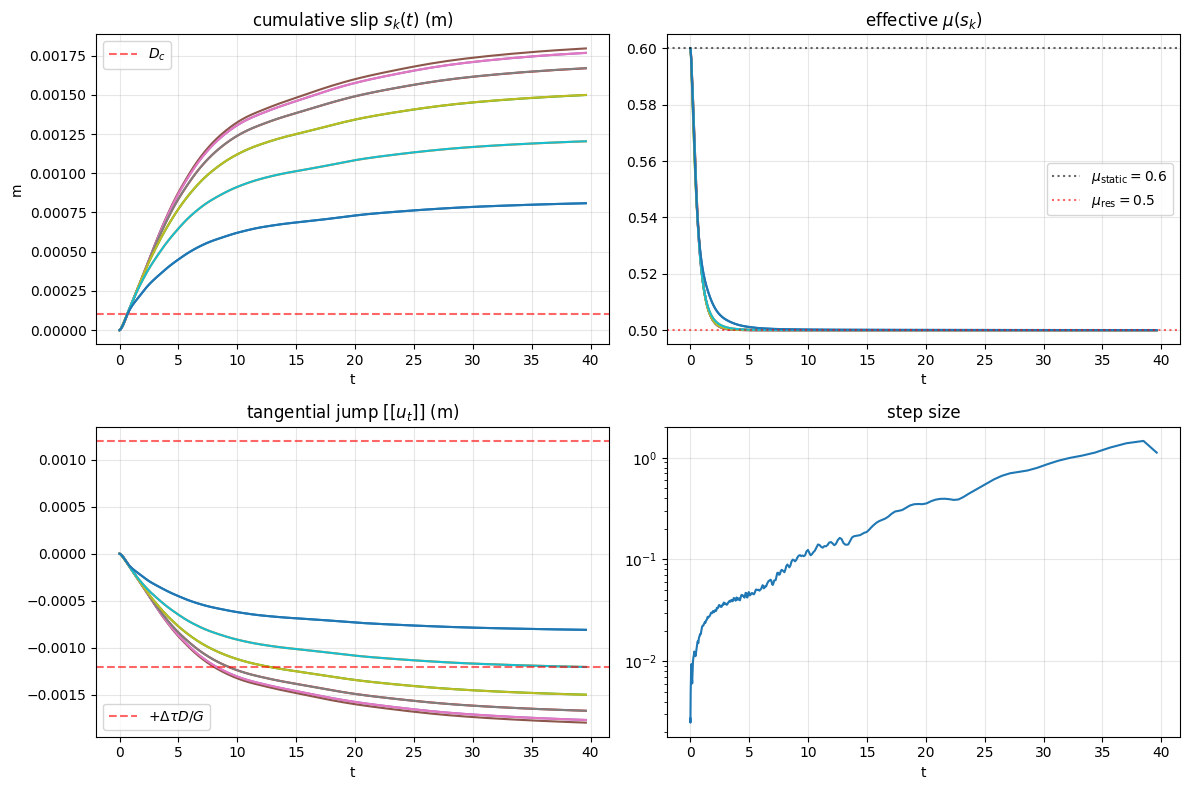

Validation summary (slip-weakening):
  QS-stable predicted:                 False  (G/D vs -Δμ σ_N/Dc)
  EQ-like slip predicted (user form):  True
  numerical max |[[u_t]]| / expected:  1.496
  mu reached residual?                 True


In [51]:
# === Plot slip-weakening response ========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(t_sw, slip_state_sw * DISP_SCALE)
axes[0, 0].axhline(DC_PHYS_SW, color='r', ls='--', alpha=0.6, label=r'$D_c$')
axes[0, 0].set_title(r'cumulative slip $s_k(t)$ (m)')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('m')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(t_sw, mu_eff_sw)
axes[0, 1].axhline(MU_STATIC_SW, color='k', ls=':', alpha=0.6,
                   label=fr'$\mu_\mathrm{{static}}={MU_STATIC_SW}$')
axes[0, 1].axhline(MU_RES_SW, color='r', ls=':', alpha=0.6,
                   label=fr'$\mu_\mathrm{{res}}={MU_RES_SW}$')
axes[0, 1].set_title(r'effective $\mu(s_k)$')
axes[0, 1].set_xlabel('t')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(t_sw, sliding_jump_sw * DISP_SCALE)
axes[1, 0].axhline(expd_slip_phys, color='r', ls='--', alpha=0.6,
                   label=r'$+\Delta\tau D/G$')
axes[1, 0].axhline(-expd_slip_phys, color='r', ls='--', alpha=0.6)
axes[1, 0].set_title(r'tangential jump $[[u_t]]$ (m)')
axes[1, 0].set_xlabel('t')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].semilogy(t_sw[1:], np.diff(t_sw))
axes[1, 1].set_title('step size')
axes[1, 1].set_xlabel('t')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Validation summary (slip-weakening):")
print(f"  QS-stable predicted:                 {stable_qs}  (G/D vs -Δμ σ_N/Dc)")
print(f"  EQ-like slip predicted (user form):  {EQslip}")
print(f"  numerical max |[[u_t]]| / expected:  "
      f"{slip_max_phys / max(expd_slip_phys, 1e-30):.3f}")
print(f"  mu reached residual?                 "
      f"{abs(mu_eff_sw.min() - MU_RES_SW) < 1e-3}")


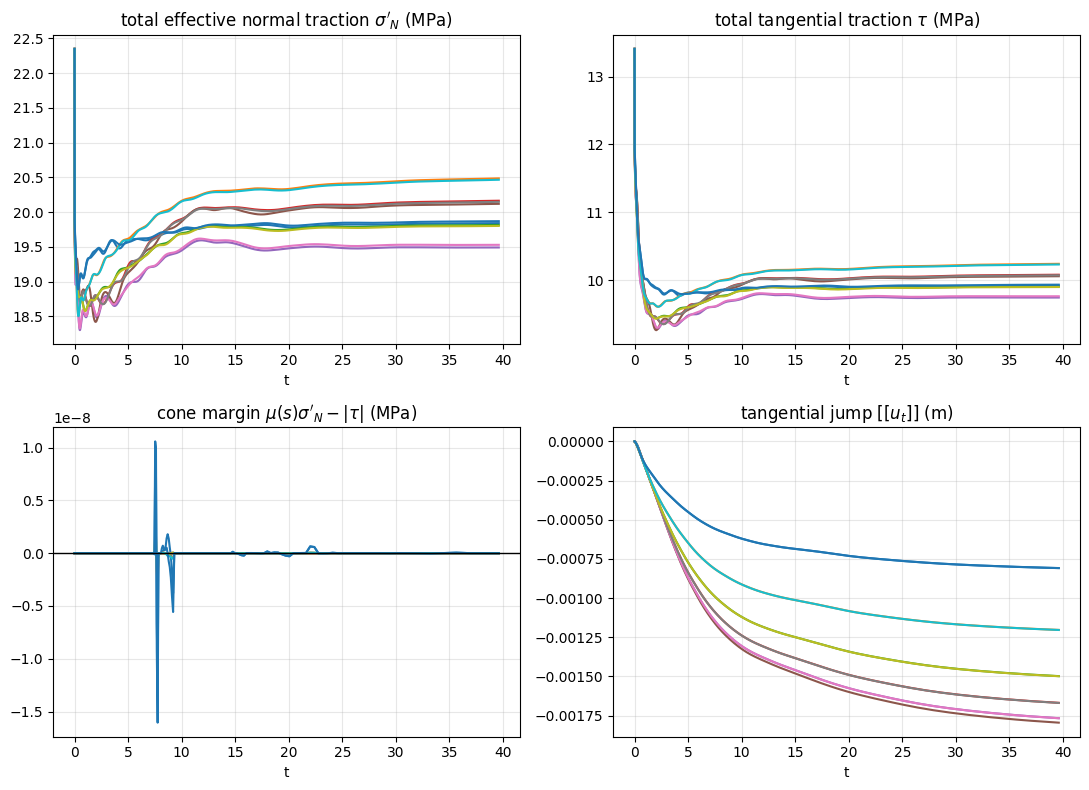

final min cone margin MPa: -3.737455e-12
final max |cone margin| MPa: 3.737455e-12


In [52]:
# === Slip-weakening: dimensional traction / cone-margin / slip plots ====
r_pert_sw, r_total_sw_nd, r_n_sw_nd, r_t_sw_nd = _contact_history(
    y_sw, n_aug_sw, n_c_s, _s0_val_s, _w0_val_s,
)
r_n_sw = r_n_sw_nd * Sigma_scale                              # MPa, σ'_N
r_t_sw = r_t_sw_nd * Sigma_scale                              # MPa, τ
cone_margin_sw = mu_eff_sw * r_n_sw - np.abs(r_t_sw)          # MPa, μ(s)σ'_N − |τ|

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].plot(t_sw, r_n_sw)
axes[0, 0].set_title(r"total effective normal traction $\sigma'_N$ (MPa)")
axes[0, 0].set_xlabel('t'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(t_sw, r_t_sw)
axes[0, 1].set_title(r"total tangential traction $\tau$ (MPa)")
axes[0, 1].set_xlabel('t'); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t_sw, cone_margin_sw)
axes[1, 0].axhline(0, color='k', lw=1)
axes[1, 0].set_title(r"cone margin $\mu(s)\sigma'_N - |\tau|$ (MPa)")
axes[1, 0].set_xlabel('t'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t_sw, sliding_jump_sw * DISP_SCALE)
axes[1, 1].set_title(r"tangential jump $[[u_t]]$ (m)")
axes[1, 1].set_xlabel('t'); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"final min cone margin MPa: {cone_margin_sw[-1].min():.6e}")
print(f"final max |cone margin| MPa: {np.max(np.abs(cone_margin_sw[-1])):.6e}")


In [53]:
# === Slip-weakening: dimensional full-field dashboard ===================
_taylor_order_sw = 2 if poro_s.include_hessian else 1
z_sw = y_sw[:, :n_base_s]

fields_sw = poro_s.sol_to_fields_dict_with_dimensions(
    np.asarray(t_sw), z_sw.T,
    use_taylor_correction=True,
    taylor_order=_taylor_order_sw,
    constrained_l2=False,
)
fields_sw['y_raw'] = z_sw.T
fields_sw['t_raw'] = np.asarray(t_sw)
print(f"Fields extracted ({len(fields_sw)} keys, taylor_order={_taylor_order_sw})")

dashboard_sw = CGPoroelasticDashboard(poro_s, fields_sw, levels=40)
dashboard_sw.show()


Fields extracted (13 keys, taylor_order=1)


## 11. Validation Summary

Compare the locked and sliding test results against the analytical Mohr-Coulomb prediction.
Overlay the numerical reaction data on the Mohr circle.

In [54]:
locked_checks_pass = bool(globals().get('locked_checks_pass', False))
sliding_checks_pass = bool(globals().get('sliding_checks_pass', False))

locked_result = 'PASS' if locked_checks_pass else 'FAIL'
sliding_result = 'PASS' if sliding_checks_pass else 'FAIL'

print("Projected Radau alpha-zero embedded-crack validation summary")
print("=========================================================")
print(f"Locked  θ={np.rad2deg(THETA_LOCKED):.1f}° predicted inside cone:  "
      f"|τ|={abs(tau_locked_val):.3f} < μσN={MU*sigma_N_locked:.3f} MPa")
print(f"Sliding θ={np.rad2deg(THETA_SLIDING):.1f}° predicted outside cone: "
      f"|τ|={abs(tau_sliding_val):.3f} > μσN={MU*sigma_N_sliding:.3f} MPa")
print(f"Locked  result: {locked_result}")
print(f"Sliding result: {sliding_result}")
print(f"Validation: {'PASS' if (locked_checks_pass and sliding_checks_pass) else 'FAIL'}")


Projected Radau alpha-zero embedded-crack validation summary
Locked  θ=20.0° predicted inside cone:  |τ|=12.856 < μσN=27.193 MPa
Sliding θ=60.0° predicted outside cone: |τ|=17.321 > μσN=12.000 MPa
Locked  result: PASS
Sliding result: PASS
Validation: PASS


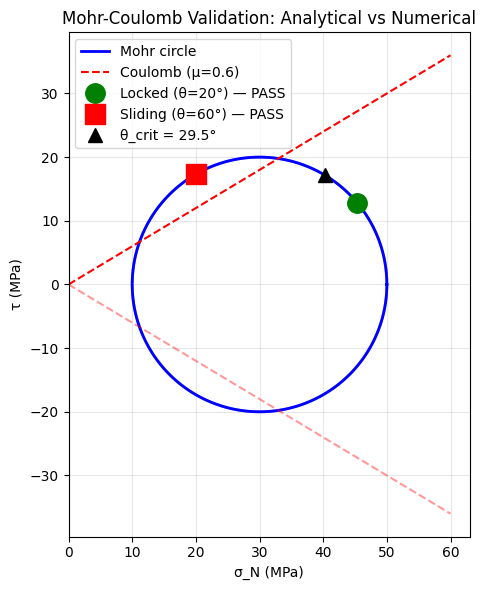

In [55]:
if LOADING_MODE != 'prestress':
    print(f"[LOADING_MODE={LOADING_MODE!r}] skipping locked-test cell")
else:
    fig, ax = plt.subplots(figsize=(8, 6))

    theta_range = np.linspace(0, np.pi, 300)
    sN_range, tau_range = mohr_tractions(theta_range)
    ax.plot(sN_range, tau_range, 'b-', lw=2, label='Mohr circle')
    ax.plot(sN_range, -tau_range, 'b-', lw=2, alpha=0.4)

    sN_env = np.linspace(0, S1 * 1.2, 100)
    ax.plot(sN_env, MU * sN_env, 'r--', lw=1.5, label=f'Coulomb (μ={MU})')
    ax.plot(sN_env, -MU * sN_env, 'r--', lw=1.5, alpha=0.4)

    ax.plot(sigma_N_locked, tau_locked_val, 'go', ms=14, zorder=5,
            label=f'Locked (θ={np.degrees(THETA_LOCKED):.0f}°) — {locked_result}')
    ax.plot(sigma_N_sliding, tau_sliding_val, 'rs', ms=14, zorder=5,
            label=f'Sliding (θ={np.degrees(THETA_SLIDING):.0f}°) — {sliding_result}')

    sN_crit, tau_crit = mohr_tractions(theta_crit)
    ax.plot(sN_crit, tau_crit, 'k^', ms=10, zorder=5,
            label=f'θ_crit = {np.degrees(theta_crit):.1f}°')

    ax.set_xlabel('σ_N (MPa)')
    ax.set_ylabel('τ (MPa)')
    ax.set_title('Mohr-Coulomb Validation: Analytical vs Numerical')
    ax.legend(loc='upper left')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()